In [1]:
# libraries
# require(eulerr)
require(ggplot2)
require(ggalluvial)
# library(VennDiagram)
# library(ggVennDiagram)

Loading required package: ggplot2

Loading required package: ggalluvial

Warning message:
“package ‘ggalluvial’ was built under R version 4.1.3”


In [2]:
sessionInfo()

R version 4.1.2 (2021-11-01)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: CentOS Linux 7 (Core)

Matrix products: default
BLAS/LAPACK: /work/project/ladcol_011/conda_path/miniconda3/envs/community_paper/lib/libopenblasp-r0.3.26.so

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=de_DE.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=de_DE.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=de_DE.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=de_DE.UTF-8 LC_IDENTIFICATION=C       

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] ggalluvial_0.12.5 ggplot2_3.5.2    

loaded via a namespace (and not attached):
 [1] magrittr_2.0.3    tidyselect_1.2.1  munsell_0.5.1     uuid_1.2-1       
 [5] colorspace_2.1-1  R6_2.5.1          rlang_1.1.4       fastmap_1.2.0    
 [9] fansi_1.0.6       dplyr_1.

In [3]:
# library(svglite)

In [3]:
community_input_dir <- "../../compare_algorithms/prepare_data/run_community/outs/"
cpdb_input_dir <- "../../compare_algorithms/prepare_data/run_CellPhoneDB/run_algorithm/outs/"
nn_input_dir <- "../../compare_algorithms/prepare_data/run_NicheNet/run_algorithm/outs/"
cellchat_input_dir <- "../../compare_algorithms/prepare_data/run_CellChat/run_algorithm/outs/"

In [4]:
scseqcom_input_dir <- "/work/project/ladcol_011/MariaWF/scseqcom/outs/"

Load data.

In [5]:
suppressWarnings(load(paste0(community_input_dir,"community_interactions.RData")))
print(str(community_interactions))

List of 23
 $ per_sample_anno_interactions:List of 13
  ..$ AML-0024    :'data.frame':	151744 obs. of  29 variables:
  .. ..$ interaction_ID     : chr [1:151744] "Mono:JAG2_Mono:NOTCH1" "Mono:DLL1_Mono:NOTCH1" "Mono:IGF1_Mono:IGF1R" "Mono:JAG1_Mono:NOTCH1" ...
  .. ..$ ligand_gene_name   : chr [1:151744] "JAG2" "DLL1" "IGF1" "JAG1" ...
  .. ..$ receptor_gene_name : chr [1:151744] "NOTCH1" "NOTCH1" "IGF1R" "NOTCH1" ...
  .. ..$ sending_cell_type  : chr [1:151744] "Mono" "Mono" "Mono" "Mono" ...
  .. ..$ receiving_cell_type: chr [1:151744] "Mono" "Mono" "Mono" "Mono" ...
  .. ..$ f_s                : num [1:151744] 0.89 0.89 0.89 0.89 0.89 ...
  .. ..$ f_r                : num [1:151744] 0.89 0.89 0.89 0.89 0.89 ...
  .. ..$ f_s_max            : num [1:151744] 0.89 0.89 0.89 0.89 0.89 ...
  .. ..$ f_r_max            : num [1:151744] 0.89 0.89 0.89 0.89 0.89 ...
  .. ..$ a_s_l              : num [1:151744] 0 0 0 0 0.168 ...
  .. ..$ nr_s_l_active      : num [1:151744] 0 0 0 0 917 3190 0 0

In [6]:
# suppressWarnings(load(paste0(community_input_dir,"community_interactions_wilcox.RData")))
# print(str(community_interactions))

In [7]:
aml = community_interactions$per_sample_anno_interactions$`AML-0024`

In [8]:
aml[aml$interaction_ID == "B:ARF6_HSPC:PLD1",]

,interaction_ID,ligand_gene_name,receptor_gene_name,sending_cell_type,receiving_cell_type,f_s,f_r,f_s_max,f_r_max,a_s_l,⋯,rho_s,rho_r,rho,phi_s_l,phi_r_r,phi,p_s_l,p_r_r,p,w
,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
88053,B:ARF6_HSPC:PLD1,ARF6,PLD1,B,HSPC,0.009466297,0.00163212,0.2944043,0.3114625,0.4482759,⋯,0.03215407,0.005240183,0.0001684932,0.5977011,0,0,0.8462853,0.2611544,0.2210111,0


In [9]:
anno_community = community_interactions$anno_interactions

In [10]:
anno_community[anno_community$interaction_ID == "DC:FABP5_DC:RXRA",][,25:40]

,passed_log10_meanexpr_control_filter,passed_log10_meanexpr_case_filter,passed_log10_meanexpr_per_condition_filter,passed_QC_filter,p.value,p.adj,passed_FDR_threshold,passed_log2FC_threshold,sign,log2FC_rho_s_direction,log2FC_phi_s_l_direction,log2FC_p_s_l_direction,log2FC_rho_r_direction,log2FC_phi_r_r_direction,log2FC_p_r_r_direction,nr_comp_affected_s
,<lgl>,<lgl>,<lgl>,<lgl>,<dbl>,<dbl>,<lgl>,<lgl>,<lgl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
150883,TRUE,TRUE,TRUE,TRUE,0.1050346,0.2191198,FALSE,TRUE,FALSE,-1,-1,0,-1,0,0,2


In [5]:
write.csv(weights, "community_weigths.csv")

In [6]:
weights[rownames(weights)=="Ery:TOR2A_Mono:ATP5F1B",]

,AML-0024,AML-0160,AML-0693,AML-1371,AML-2123,AML-3133,AML-4340,healthy-1,healthy-2,healthy-3,healthy-4,healthy-4003,healthy-5
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Ery:TOR2A_Mono:ATP5F1B,0,0,0.0009373687,0,0,0.0007673831,0,0.003612173,0.005952376,0.0009626915,0.005018218,0.001022766,0.01081778


In [9]:
write.csv(community_interactions$rho_s, "rho_s.csv")
write.csv(community_interactions$rho_r, "rho_r.csv")

In [4]:
write.csv(community_interactions$phi_s_l, "phi_s_l.csv")
write.csv(community_interactions$phi_r_r, "phi_r_r.csv")

In [6]:
write.csv(community_interactions$p_s_l, "p_s_l.csv")
write.csv(community_interactions$p_r_r, "p_r_r.csv")

In [11]:
anno_community = community_interactions$anno_interactions

In [12]:
dim(anno_community[is.na(anno_community$p.value),])

[1] 142544     52

In [13]:
min(anno_community[!is.na(anno_community$p.value),]$p.value)

[1] 3.68338e-08

In [14]:
anno_community[anno_community$interaction_ID == "Mono:HMGB1_T:CXCR4",]

,interaction_ID,ligand_gene_name,receptor_gene_name,sending_cell_type,receiving_cell_type,mean_e_s_l_control,mean_e_s_l_case,mean_e_r_r_control,mean_e_r_r_case,log2FC_rho_s,⋯,components_affected_s,components_affected_r,sender_or_receiver_affected,direction_s,direction_r,direction_b,concordance_s,concordance_r,concordance_b,interaction_category
,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<chr>,<chr>,<ord>,<ord>,<ord>,<ord>,<ord>,<ord>,<ord>,<chr>
6292,Mono:HMGB1_T:CXCR4,HMGB1,CXCR4,Mono,T,2.098544,2.001264,1.962705,2.394566,-0.4546995,⋯,none,none,none,none,none,none,undefined,undefined,undefined,no_change


In [8]:
# write.csv(anno_community, file = 'anno_df.csv')

In [15]:
dim(anno_community[anno_community$passed_frac_samples_filter,])

[1] 9739   52

In [16]:
dim(anno_community[!anno_community$passed_frac_samples_filter,])

[1] 142005     52

In [12]:
# anno_community$p.value.alt <- p.adjust(anno_community$p.value
#                                      ,method = 'fdr')

In [13]:
# anno_community[c('p.value.alt', 'p.adj')]

In [14]:
# anno_community[is.na(anno_community$p.value),]

In [17]:
suppressWarnings(load(paste0(cpdb_input_dir,"cpdb_interactions.RData")))
print(str(cpdb_interactions))

List of 2
 $ weights          : tibble [5,732 × 14] (S3: tbl_df/tbl/data.frame)
  ..$ interaction_ID: chr [1:5732] "B:ALCAM_NK:CD6" "DC:ALCAM_NK:CD6" "Gran:ALCAM_NK:CD6" "HSPC:ALCAM_NK:CD6" ...
  ..$ AML-0024      : int [1:5732] 0 1 1 0 1 0 1 1 0 1 ...
  ..$ AML-0160      : int [1:5732] 0 0 0 0 0 0 1 1 1 1 ...
  ..$ AML-0693      : int [1:5732] 0 0 0 0 0 1 1 1 1 1 ...
  ..$ AML-1371      : int [1:5732] 1 1 1 1 1 1 1 1 1 1 ...
  ..$ AML-2123      : int [1:5732] 0 0 1 1 1 0 0 1 1 1 ...
  ..$ AML-3133      : int [1:5732] 0 1 1 1 0 0 1 1 1 0 ...
  ..$ AML-4340      : int [1:5732] 0 1 1 1 1 0 1 1 1 1 ...
  ..$ healthy-1     : int [1:5732] 0 0 0 0 0 0 1 1 1 0 ...
  ..$ healthy-2     : int [1:5732] 0 0 0 0 0 0 1 1 1 0 ...
  ..$ healthy-3     : int [1:5732] 0 0 0 0 0 0 1 1 1 0 ...
  ..$ healthy-4     : int [1:5732] 0 0 0 0 0 0 1 1 1 0 ...
  ..$ healthy-4003  : int [1:5732] 0 0 0 0 0 0 1 1 1 0 ...
  ..$ healthy-5     : int [1:5732] 0 0 0 0 0 0 1 1 1 0 ...
 $ anno_interactions:'data.frame':	5732

In [18]:
suppressWarnings(load(paste0(nn_input_dir,"nn_interactions.RData")))
print(str(nn_interactions))

List of 2
 $ weights          : tibble [10,965 × 14] (S3: tbl_df/tbl/data.frame)
  ..$ interaction_ID: chr [1:10965] "Mono:ACKR3_Mono:CXCR4" "Mono:ALOX5AP_Mono:ALOX5" "Mono:AREG_Mono:ICAM1" "Mono:CASP8_Mono:FAS" ...
  ..$ AML-0024      : num [1:10965] 0.285 3.322 1.609 0.917 3.836 ...
  ..$ AML-0160      : num [1:10965] NA 3.32 1.61 NA 3.84 ...
  ..$ AML-0693      : num [1:10965] NA 3.32 NA NA NA ...
  ..$ AML-1371      : num [1:10965] NA 3.32 NA NA NA ...
  ..$ AML-2123      : num [1:10965] NA 3.32 NA NA NA ...
  ..$ AML-3133      : num [1:10965] NA 3.32 1.61 NA NA ...
  ..$ AML-4340      : num [1:10965] NA 3.32 1.61 NA NA ...
  ..$ healthy-1     : num [1:10965] NA 3.32 1.61 NA 3.84 ...
  ..$ healthy-2     : num [1:10965] NA 3.32 1.61 NA NA ...
  ..$ healthy-3     : num [1:10965] NA 3.32 1.61 NA NA ...
  ..$ healthy-4     : num [1:10965] NA 3.32 NA NA NA ...
  ..$ healthy-4003  : num [1:10965] NA 3.32 NA NA NA ...
  ..$ healthy-5     : num [1:10965] NA NA NA NA NA ...
 $ anno_interact

In [19]:
load("/work/project/ladcol_011/MariaWF/multinichenet/multinn.RData")

In [20]:
nn_interactions = multinn

In [21]:
nn_interactions$anno_interactions = as.data.frame(nn_interactions$anno_interactions)

In [22]:
suppressWarnings(load(paste0(cellchat_input_dir,"cellchat_interactions.RData")))
print(str(cellchat_interactions))

List of 2
 $ weights          :'data.frame':	6422 obs. of  13 variables:
  ..$ AML-0024    : num [1:6422] 0.006994 0.005992 0.000941 0.000805 0.010007 ...
  ..$ AML-0160    : num [1:6422] NA NA NA NA 5.47e-05 ...
  ..$ AML-0693    : num [1:6422] 0.00788 0.00199 NA NA NA ...
  ..$ AML-1371    : num [1:6422] 0.0363 0.0287 0.0143 0.0112 NA ...
  ..$ AML-2123    : num [1:6422] NA NA NA NA NA NA NA NA NA NA ...
  ..$ AML-3133    : num [1:6422] 0.01865 0.01137 0.00172 0.00104 NA ...
  ..$ AML-4340    : num [1:6422] NA NA NA NA NA NA NA NA NA NA ...
  ..$ healthy-1   : num [1:6422] NA NA NA NA NA NA NA NA NA NA ...
  ..$ healthy-2   : num [1:6422] NA NA NA NA NA NA NA NA NA NA ...
  ..$ healthy-3   : num [1:6422] NA NA NA NA NA NA NA NA NA NA ...
  ..$ healthy-4   : num [1:6422] NA NA NA NA NA NA NA NA NA NA ...
  ..$ healthy-4003: num [1:6422] NA NA NA NA NA NA NA NA NA NA ...
  ..$ healthy-5   : num [1:6422] NA NA NA NA NA NA NA NA NA NA ...
 $ anno_interactions:'data.frame':	6422 obs. of  

In [23]:
idx_good <- community_interactions$anno_interactions$passed_QC_filter
id_good <- community_interactions$anno_interactions$interaction_ID[idx_good]
id_bad <- community_interactions$anno_interactions$interaction_ID[!idx_good]
cellchat_interactions$anno_interactions$community_QC = cellchat_interactions$anno_interactions$interaction_ID %in% id_good

In [24]:
nn_interactions$anno_interactions$community_QC = nn_interactions$anno_interactions$interaction_ID %in% id_good

In [25]:
cpdb_interactions$anno_interactions$community_QC = cpdb_interactions$anno_interactions$interaction_ID %in% id_good

In [26]:
write.csv(cellchat_interactions$anno_interactions, "cellchat_qc.csv")

In [25]:
write.csv(nn_interactions$anno_interactions, "nn_qc.csv")

In [21]:
write.csv(cpdb_interactions$anno_interactions, "cpdb_qc.csv")

In [27]:
getwd()

[1] "/work/project/ladcol_011/MariaWF/community-paper/src/method_comparison/compare_algorithms/compare_results"

In [27]:
idx_good <- community_interactions$anno_interactions$passed_QC_filter

id_good <- community_interactions$anno_interactions$interaction_ID[idx_good]
id_bad <- community_interactions$anno_interactions$interaction_ID[!idx_good]


In [28]:
suppressWarnings(load(paste0(scseqcom_input_dir,"scseqcom_interactions.RData")))
print(str(scseqcom_interactions))

List of 2
 $ anno_interactions:'data.frame':	9381 obs. of  16 variables:
  ..$ sender_gene           : chr [1:9381] "GAS6" "LTA" "LTA" "GAS6" ...
  ..$ receiver_gene         : chr [1:9381] "MERTK" "TNFRSF14" "TNFRSF1B" "TYRO3" ...
  ..$ LR_pair               : chr [1:9381] "GAS6 - MERTK" "LTA - TNFRSF14" "LTA - TNFRSF1B" "GAS6 - TYRO3" ...
  ..$ sender_celltype       : chr [1:9381] "B" "B" "B" "B" ...
  ..$ receiver_celltype     : chr [1:9381] "B" "B" "B" "B" ...
  ..$ interaction           : chr [1:9381] "B --> B" "B --> B" "B --> B" "B --> B" ...
  ..$ S_inter_AML           : num [1:9381] 8.51e-11 1.18e-01 1.18e-01 0.00 4.59e-10 ...
  ..$ S_inter_healthy       : num [1:9381] 0.001407 0.000246 0.000246 0.001179 0.001678 ...
  ..$ logFC_S_inter         : num [1:9381] -23.98 8.91 8.91 -Inf -21.8 ...
  ..$ mean_S_inter          : num [1:9381] 0.000703 0.059194 0.059194 0.000589 0.000839 ...
  ..$ pvalue_S_inter        : num [1:9381] 0.01608 0.0123 0.0123 0.00145 0.01608 ...
  ..$ effsize

In [29]:
anno_community = community_interactions$anno_interactions
anno_community[anno_community$interaction_ID == "Mono:HMGB1_T:CXCR4",]

,interaction_ID,ligand_gene_name,receptor_gene_name,sending_cell_type,receiving_cell_type,mean_e_s_l_control,mean_e_s_l_case,mean_e_r_r_control,mean_e_r_r_case,log2FC_rho_s,⋯,components_affected_s,components_affected_r,sender_or_receiver_affected,direction_s,direction_r,direction_b,concordance_s,concordance_r,concordance_b,interaction_category
,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<chr>,<chr>,<ord>,<ord>,<ord>,<ord>,<ord>,<ord>,<ord>,<chr>
6292,Mono:HMGB1_T:CXCR4,HMGB1,CXCR4,Mono,T,2.098544,2.001264,1.962705,2.394566,-0.4546995,⋯,none,none,none,none,none,none,undefined,undefined,undefined,no_change


In [30]:
anno_cpdb = cpdb_interactions$anno_interactions
anno_cpdb[anno_cpdb$interaction_ID == "Mono:HMGB1_T:CXCR4",]

,interaction_ID,sender_celltype,sender_gene,receiver_celltype,receiver_gene,ligand_log2FC,ligand_p_val_adj,receptor_log2FC,receptor_p_val_adj,direction,direction_lig,direction_rec,direction_lig_rec,community_QC
,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<lgl>
18831,Mono:HMGB1_T:CXCR4,Mono,HMGB1,T,CXCR4,NA,NA,0.6280541,0,up,NA,up,NA_up,TRUE


In [31]:
anno_nn = nn_interactions$anno_interactions
anno_nn[anno_nn$interaction_ID == "Mono:HMGB1_T:CXCR4",]

,group,sender,receiver,ligand,receptor,id,prioritization_score,prioritization_rank,ligand_p_val,ligand_logFC,receptor_p_val,receptor_logFC,interaction_ID,direction_lig,direction_rec,direction_lig_rec,direction,community_QC
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>
10463,AML,Mono,T,HMGB1,CXCR4,HMGB1_CXCR4_Mono_T,0.6133584,10463,0.627,-0.0641,0.00511,0.763,Mono:HMGB1_T:CXCR4,down,up,down_up,ambigous,TRUE


In [32]:
anno_cellchat = cellchat_interactions$anno_interactions
anno_cellchat[anno_cellchat$interaction_ID == "Mono:HMGB1_T:CXCR4",]

,sending_celltype,receiving_celltype,sender_gene,receiving_gene,prob,pval,interaction_name,interaction_name_2,pathway_name,datasets,⋯,receptor.pct.1,receptor.pct.2,receptor.pvalues,interaction_ID,direction_lig,direction_rec,direction_lig_rec,direction,average_logFC,community_QC
,<fct>,<fct>,<chr>,<chr>,<dbl>,<dbl>,<fct>,<chr>,<chr>,<chr>,⋯,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<lgl>
5772,Mono,T,HMGB1,CXCR4,0.1497578,0,HMGB1_CXCR4,HMGB1 - CXCR4,,AML-0024,⋯,88.89938,51.77063,0,Mono:HMGB1_T:CXCR4,down,up,down_up,ambigous,0.5020215,TRUE


In [33]:
anno_scseqcom = scseqcom_interactions$anno_interactions
anno_scseqcom[anno_scseqcom$interaction_ID == "Mono:HMGB1_T:CXCR4",]

sender_gene,receiver_gene,LR_pair,sender_celltype,receiver_celltype,interaction,S_inter_AML,S_inter_healthy,logFC_S_inter,mean_S_inter,pvalue_S_inter,effsize_S_inter,effsize_symbol_S_inter,pvalue_adj_S_inter,direction,interaction_ID
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<chr>


In [34]:
cellchat_interactions$weights[rownames(cellchat_interactions$weights) == "Mono:HMGB1_T:CXCR4",]

,AML-0024,AML-0160,AML-0693,AML-1371,AML-2123,AML-3133,AML-4340,healthy-1,healthy-2,healthy-3,healthy-4,healthy-4003,healthy-5
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Mono:HMGB1_T:CXCR4,0.1497578,NA,0.0865887,0.1738265,NA,0.1398715,NA,NA,NA,NA,NA,NA,NA


In [35]:
head(cpdb_interactions$weights)

interaction_ID,AML-0024,AML-0160,AML-0693,AML-1371,AML-2123,AML-3133,AML-4340,healthy-1,healthy-2,healthy-3,healthy-4,healthy-4003,healthy-5
<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
B:ALCAM_NK:CD6,0,0,0,1,0,0,0,0,0,0,0,0,0
DC:ALCAM_NK:CD6,1,0,0,1,0,1,1,0,0,0,0,0,0
Gran:ALCAM_NK:CD6,1,0,0,1,1,1,1,0,0,0,0,0,0
HSPC:ALCAM_NK:CD6,0,0,0,1,1,1,1,0,0,0,0,0,0
Mono:ALCAM_NK:CD6,1,0,0,1,1,0,1,0,0,0,0,0,0
B:ALCAM_T:CD6,0,0,1,1,0,0,0,0,0,0,0,0,0


In [36]:
head(cellchat_interactions$weights)

,AML-0024,AML-0160,AML-0693,AML-1371,AML-2123,AML-3133,AML-4340,healthy-1,healthy-2,healthy-3,healthy-4,healthy-4003,healthy-5
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
NK:TGFB1_NK:TGFBR3,0.0069939380,NA,0.007884556,0.03626334,NA,0.018647469,NA,NA,NA,NA,NA,NA,NA
T:TGFB1_NK:TGFBR3,0.0059918655,NA,0.001992708,0.02866503,NA,0.011366258,NA,NA,NA,NA,NA,NA,NA
NK:TGFB1_T:TGFBR3,0.0009408477,NA,NA,0.01429447,NA,0.001715363,NA,NA,NA,NA,NA,NA,NA
T:TGFB1_T:TGFBR3,0.0008053422,NA,NA,0.01124562,NA,0.001038575,NA,NA,NA,NA,NA,NA,NA
Mono:ADM_DC:RAMP1,0.0100074770,5.467536e-05,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
Mono:ADM_NK:RAMP1,0.0055381506,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA


In [37]:
cpdb_interactions$anno_interactions[cpdb_interactions$anno_interactions$interaction_ID=="Mono:HMGB1_T:CXCR4",]

,interaction_ID,sender_celltype,sender_gene,receiver_celltype,receiver_gene,ligand_log2FC,ligand_p_val_adj,receptor_log2FC,receptor_p_val_adj,direction,direction_lig,direction_rec,direction_lig_rec,community_QC
,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<lgl>
18831,Mono:HMGB1_T:CXCR4,Mono,HMGB1,T,CXCR4,NA,NA,0.6280541,0,up,NA,up,NA_up,TRUE


In [38]:
scseqcom_interactions$anno_interactions[scseqcom_interactions$anno_interactions$interaction_ID=="Mono:HMGB1_T:CXCR4",]

sender_gene,receiver_gene,LR_pair,sender_celltype,receiver_celltype,interaction,S_inter_AML,S_inter_healthy,logFC_S_inter,mean_S_inter,pvalue_S_inter,effsize_S_inter,effsize_symbol_S_inter,pvalue_adj_S_inter,direction,interaction_ID
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<chr>


In [39]:
cellchat_interactions$anno_interactions[cellchat_interactions$anno_interactions$interaction_ID=="Mono:HMGB1_T:CXCR4",]

,sending_celltype,receiving_celltype,sender_gene,receiving_gene,prob,pval,interaction_name,interaction_name_2,pathway_name,datasets,⋯,receptor.pct.1,receptor.pct.2,receptor.pvalues,interaction_ID,direction_lig,direction_rec,direction_lig_rec,direction,average_logFC,community_QC
,<fct>,<fct>,<chr>,<chr>,<dbl>,<dbl>,<fct>,<chr>,<chr>,<chr>,⋯,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<lgl>
5772,Mono,T,HMGB1,CXCR4,0.1497578,0,HMGB1_CXCR4,HMGB1 - CXCR4,,AML-0024,⋯,88.89938,51.77063,0,Mono:HMGB1_T:CXCR4,down,up,down_up,ambigous,0.5020215,TRUE


In [40]:
# check if all interaction IDs for CPDB are in community (all)
all(cpdb_interactions$anno_interactions$interaction_ID %in% community_interactions$anno_interactions$interaction_ID)

[1] TRUE

In [41]:
# check if all interaction IDs for NN are in community (all)
all(nn_interactions$anno_interactions$interaction_ID %in% community_interactions$anno_interactions$interaction_ID)

[1] TRUE

In [42]:
# check if all interaction IDs for NN are in community (all)
all(nn_interactions$anno_interactions$interaction_ID %in% community_interactions$anno_interactions$interaction_ID)

[1] TRUE

In [43]:
# check if all interaction IDs for CellChat are in community (all)
all(cellchat_interactions$anno_interactions$interaction_ID %in% community_interactions$anno_interactions$interaction_ID)

[1] TRUE

In [44]:
# check if all interaction IDs for CellChat are in community (all)
all(scseqcom_interactions$anno_interactions$interaction_ID %in% community_interactions$anno_interactions$interaction_ID)

[1] TRUE

# plot data

## Euler diagram of differential interactions

In [45]:
# index of significant interactions in community
idx_sign <- !is.na(community_interactions$anno_interactions$sign) & community_interactions$anno_interactions$sign

In [46]:
idx_sign_nn <- !is.na(nn_interactions$anno_interactions$sign) & nn_interactions$anno_interactions$sign

In [47]:
dim(nn_interactions$anno_interactions[idx_sign_nn,])

[1]  0 18

In [270]:
getwd()

[1] "/work/project/ladcol_011/MariaWF/community-paper/src/method_comparison/compare_algorithms/compare_results"

In [48]:
community_set1 <- community_interactions$anno_interactions$interaction_ID[idx_sign]
CellPhoneDB_set2 <- cpdb_interactions$anno_interactions$interaction_ID
# NicheNet_set3 <- nn_interactions$anno_interactions$interaction_ID[idx_sign_nn]
NicheNet_set3 <- nn_interactions$anno_interactions$interaction_ID
CellChat_set4 <- cellchat_interactions$anno_interactions$interaction_ID
scseq_set5 <- scseqcom_interactions$anno_interactions$interaction_ID

In [49]:
all_differential_interactions <- unique(c(community_set1, CellPhoneDB_set2, NicheNet_set3, CellChat_set4, scseq_set5))

differential_interaction_df <- data.frame(
  interaction_ID = all_differential_interactions,
  community = all_differential_interactions %in% community_set1,
  CPDB = all_differential_interactions %in% CellPhoneDB_set2,
  NicheNet = all_differential_interactions %in% NicheNet_set3,
  CellChat = all_differential_interactions %in% CellChat_set4,
  scSeqCom = all_differential_interactions %in% scseq_set5
)


In [415]:
write.csv(differential_interaction_df,"outs/differential_interactions.csv", row.names = FALSE)

In [81]:
  venn_list <- list(
    Community = community_set1,
    CellPhoneDB = CellPhoneDB_set2,
    NicheNet = NicheNet_set3,
    CellChat = CellChat_set4
  )

In [82]:
set_sizes <- c(length(community_set1), length(CellPhoneDB_set2), length(NicheNet_set3), length(CellChat_set4))

category_names <- paste0(
    c("community", "CPDB", "NicheNet", "CellChat"), 
    "\n(", set_sizes, ")"
  )

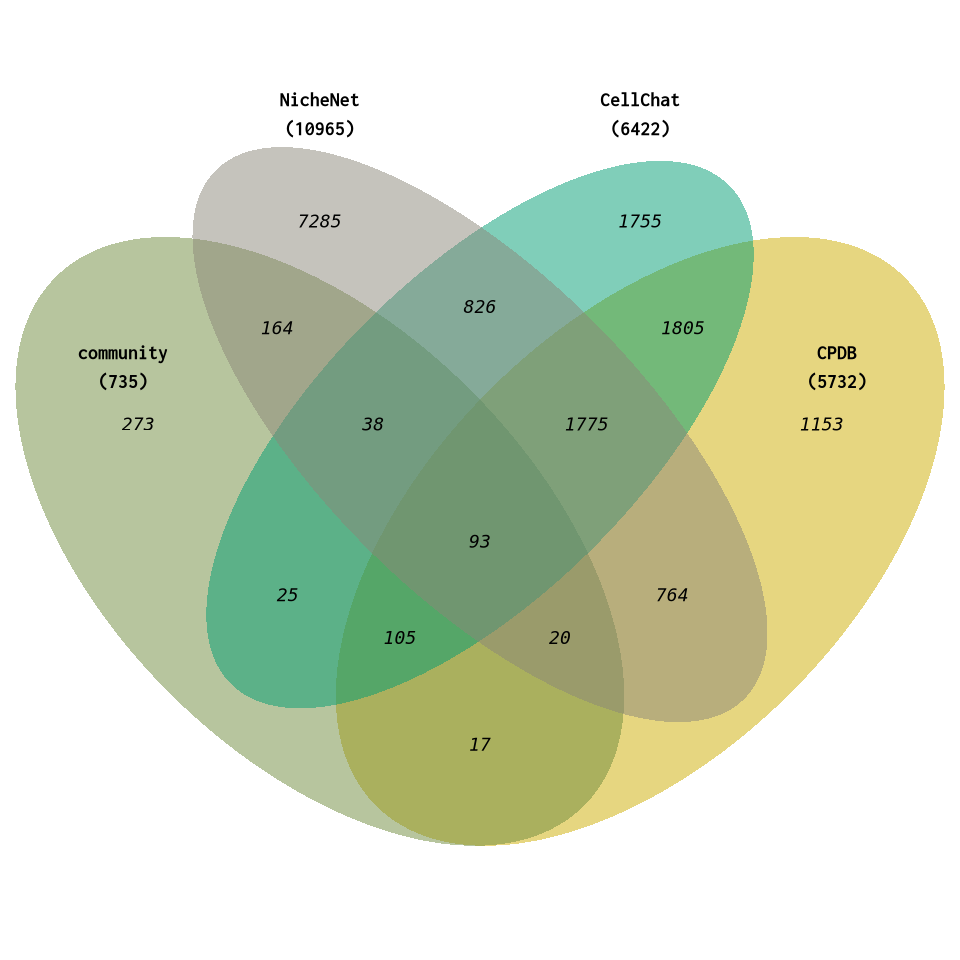

In [177]:
venn.plot <- venn.diagram(
    x = venn_list,
    category.names = category_names,  
    lwd = 2,
    lty = 'blank',
    fill = c("darkolivegreen4", "gold3", "cornsilk4", "#009E73"),
    cex = 0.9,
    fontface = "italic",
    cat.cex = 1,
    cat.fontface = "bold",
    cat.default.pos = "outer",
    cat.dist = c(0.055, 0.055, 0.1, 0.1),
    filename = NULL,  
    output = TRUE
  )
  
  ggsave(file="outs/differential_interactions.png", plot=venn.plot, width=10, height=8, dpi = 300)
  grid.draw(venn.plot)

In [178]:
  venn_colors <- c(
    "#1B7837",   # Community
    "#5AAE61",   # CellPhoneDB 5AAE61
    "#ACD39E",   # NicheNet ACD39E
    "#D6F0D3"    # CellChat
  )

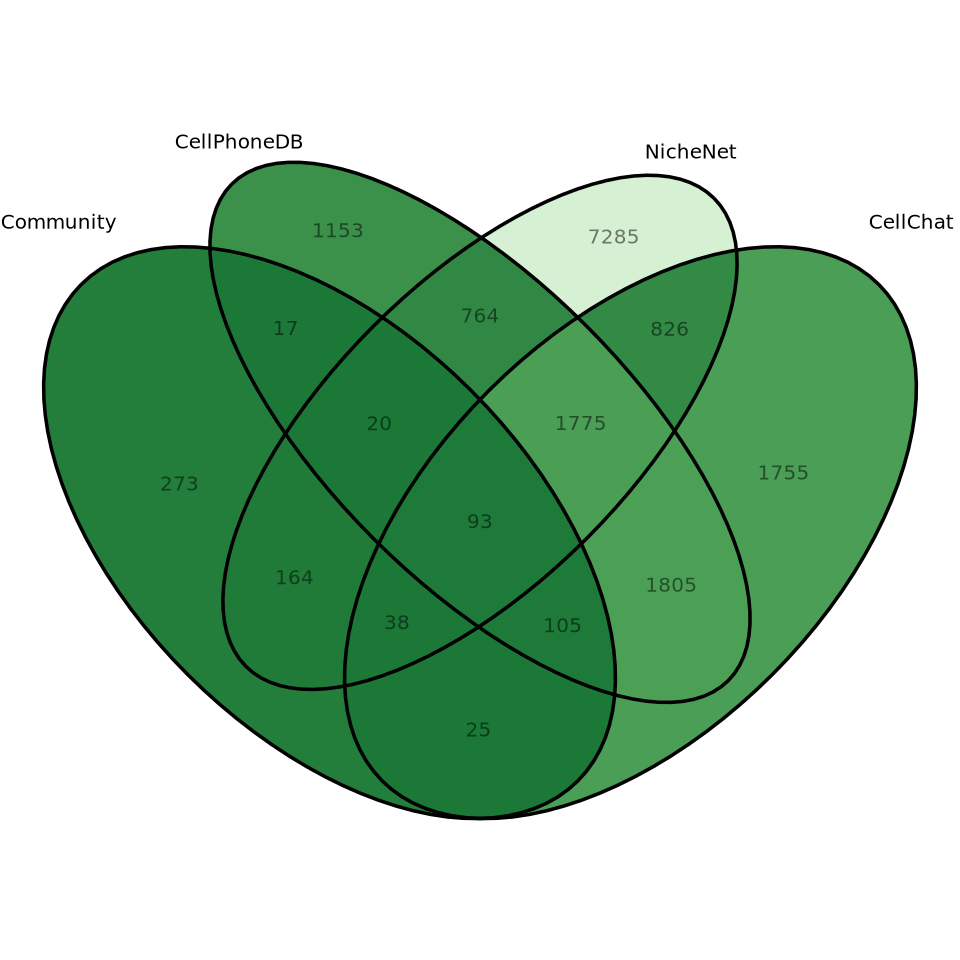

In [179]:
named_venn <- list(
"Community" = venn_list$Community,
"CellPhoneDB" = venn_list$CellPhoneDB,
"NicheNet" = venn_list$NicheNet,
"CellChat" = venn_list$CellChat
)

# Create the Venn diagram using ggVennDiagram
venn_plot <- ggVennDiagram(named_venn, label = "count", label_geom = "text") +
scale_fill_gradientn(colors = venn_colors) +  # Apply the gradient of colors
theme(legend.position = "none")  # Customize the theme

grid.draw(venn_plot)

In [180]:
# int_list <- list(community = community_interactions$anno_interactions$interaction_ID[idx_sign]
#                 ,NicheNet = nn_interactions$anno_interactions$interaction_ID
#                 ,CellPhoneDB = cpdb_interactions$anno_interactions$interaction_ID
#                 ,CellChat = cellchat_interactions$anno_interactions$interaction_ID
#                 )

# # add numbers to the names
# numbers <- c(sum(idx_sign)
#             ,length(nn_interactions$anno_interactions$interaction_ID)
#             ,length(cpdb_interactions$anno_interactions$interaction_ID)
#             ,length(cellchat_interactions$anno_interactions$interaction_ID)
#             )
# names(int_list) <- paste0(names(int_list)
#                          ,"\n"
#                          ,"("
#                          ,numbers
#                          ,")")

# plot(euler(int_list
#           )
#      ,fills = c(community = "darkolivegreen4"
#                 ,NicheNet = "gold3"
#                 ,CellPhoneDB = "cornsilk4"#"rosybrown"
#                )
#      ,alpha=c(1,0.5,0.5)
#      ,quantities = list(fontsize = 12)
#     )

## Interactions stratified by quality

In [50]:
# index of good interactions for community
idx_good <- community_interactions$anno_interactions$passed_QC_filter

In [51]:
sum(idx_good)

[1] 9200

In [53]:
sum(idx_sign)

[1] 735

In [58]:
idx_pass_fraction = community_interactions$anno_interactions$passed_frac_samples_filter

In [61]:
id_pass_fraction <- community_interactions$anno_interactions$interaction_ID[idx_pass_fraction]
id_sign <- community_interactions$anno_interactions$interaction_ID[idx_sign]

In [63]:
length(id_pass_fraction[!id_pass_fraction %in% id_sign])

[1] 9004

In [64]:
# stacked bar
id_pass_fraction <- community_interactions$anno_interactions$interaction_ID[idx_pass_fraction]
id_sign <- community_interactions$anno_interactions$interaction_ID[idx_sign]

id_pass_fraction <-id_pass_fraction[!id_pass_fraction %in% id_sign]

data <- data.frame(algorithm = c("CPDB"
                                 ,"CPDB"
                                 ,"NicheNet"
                                 , "NicheNet"
                                 ,"CellChat"
                                 ,"CellChat"
                                 ,"scSeq"
                                 ,"scSeq"
                                )
                  ,quality_by_community = c("diff"
                                           ,"not_diff"
                                           ,"diff"
                                           ,"not_diff"
                                           ,"diff"
                                           ,"not_diff"
                                            ,"diff"
                                            ,"not_diff"
                                            
                                           )
                  ,number = c(sum(cpdb_interactions$anno_interactions$interaction_ID %in% id_sign)
                              ,sum(cpdb_interactions$anno_interactions$interaction_ID %in% id_pass_fraction)
                              ,sum(nn_interactions$anno_interactions$interaction_ID %in% id_sign)
                              ,sum(nn_interactions$anno_interactions$interaction_ID %in% id_pass_fraction)
                              ,sum(cellchat_interactions$anno_interactions$interaction_ID %in% id_sign)
                              ,sum(cellchat_interactions$anno_interactions$interaction_ID %in% id_pass_fraction)
                              ,sum(scseqcom_interactions$anno_interactions$interaction_ID %in% id_sign)
                              ,sum(scseqcom_interactions$anno_interactions$interaction_ID %in% id_pass_fraction)
                             )
                  )

In [65]:
sum(nn_interactions$anno_interactions[nn_interactions$anno_interactions$interaction_ID %in% id_good,]$sign)

[1] 0

In [66]:
sum(nn_interactions$anno_interactions[nn_interactions$anno_interactions$interaction_ID %in% id_bad,]$sign)

[1] 0

In [67]:
dim(nn_interactions$anno_interactions[nn_interactions$anno_interactions$interaction_ID %in% id_good,])

[1] 8908   18

In [57]:
sum(nn_interactions$anno_interactions$sign)

[1] 0

In [61]:
data = data[data$algorithm != "scSeq",]

  algorithm quality_by_community number
1      CPDB                 diff    235
2      CPDB             not_diff   2706
3  NicheNet                 diff    713
4  NicheNet             not_diff   8716
5  CellChat                 diff    261
6  CellChat             not_diff   3439
7     scSeq                 diff    348
8     scSeq             not_diff   1303


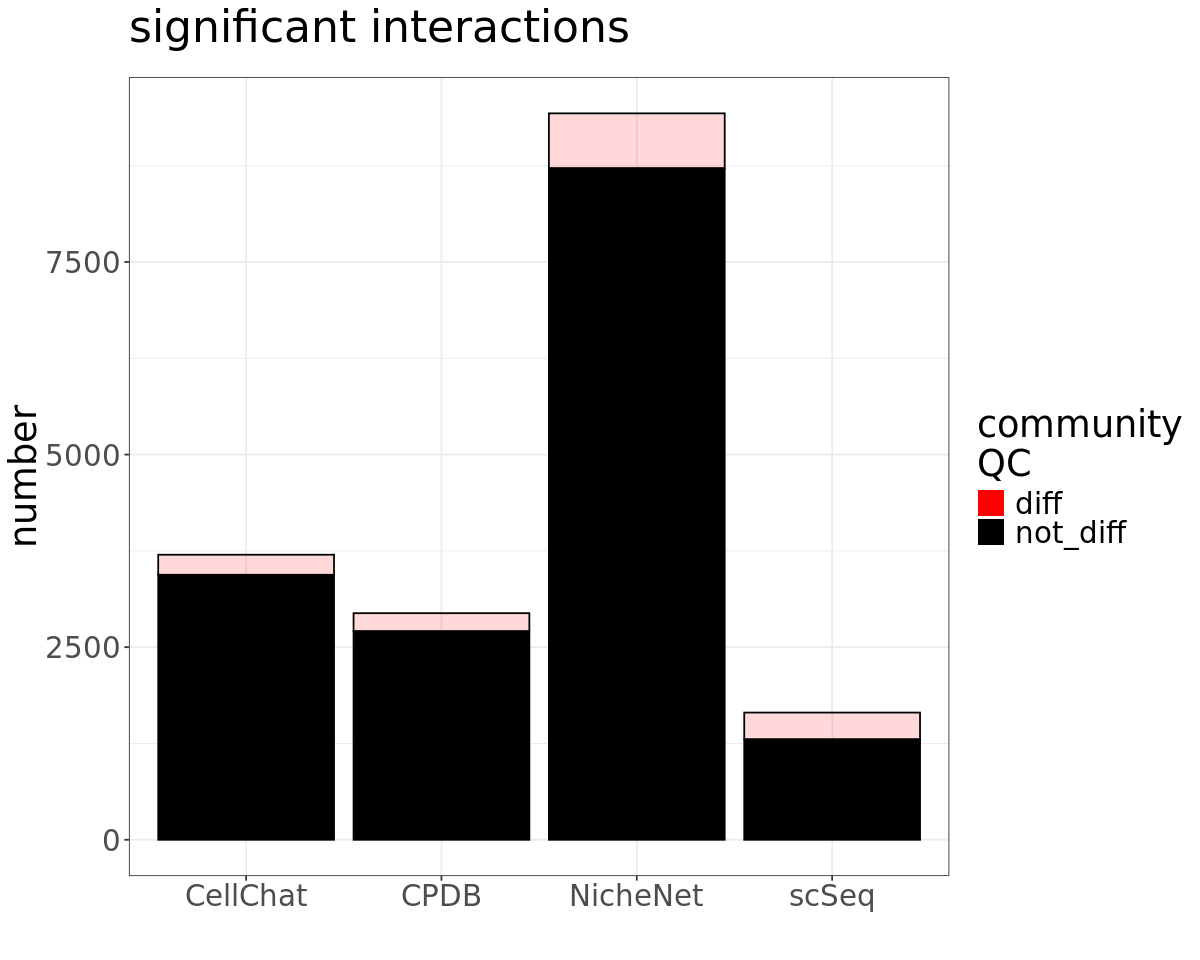

In [68]:
print(data)
options(repr.plot.width = 10
       ,repr.plot.height = 8)
plot <- ggplot(data
       , aes(x=algorithm
             , y=number
             ,fill=quality_by_community 
             ,color=quality_by_community
             ,alpha=quality_by_community
            )
      ) + 
    geom_bar(position="stack"
             ,stat="identity"
            )+
xlab("")+
ggtitle("significant interactions")+
scale_fill_manual(name = "community\nQC"
                   ,values = c("red","black")
                   )+
scale_color_manual(name= NULL
                  ,values = c("black","black")
                  ,guide = "none")+
scale_alpha_manual(name= NULL
                  ,values = c(0.15,1)
                  ,guide = "none"
                  )+
theme_bw()+
theme(text = element_text(size=22)
      ,plot.title = element_text(margin = margin(t = 0, r = 0, b = 15, l = 0))
     )

ggsave(file="outs/significant_interactions_QC.png", plot=plot, width=10, height=8, dpi = 300)

plot

In [6]:
plot_nr_samples <- function(my_df
                           ,name){
    options(repr.plot.height = 5
        ,repr.plot.width = 5)
plot <- ggplot(data = my_df
      ,aes(x = number_healthy
          ,y = number_aml
          )
      )+
geom_jitter()+ 
theme_bw()+
xlab("number of healthy samples")+
ylab("number of AML samples")+
theme(text = element_text(size=22)
      ,plot.title = element_text(margin = margin(t = 0, r = 0, b = 15, l = 0))
      ,axis.title.y = element_text(margin = margin(t = 0, r = 15, b = 0, l = 0))
     )+
ggtitle(name)
    ggsave(file=paste0("outs/", name, "_nr_samples.jpeg"), plot=plot, width=10, height=8)

    plot
}

In [425]:
scseqcom_interactions$weights <- scseqcom_interactions$weights[!duplicated(as.list(scseqcom_interactions$weights), fromLast=TRUE)]

In [426]:
head(scseqcom_interactions$weights)

,AML_1,AML_2,AML_3,AML_4,AML_5,AML_6,AML_7,healthy_1,healthy_2,healthy_3,healthy_4,healthy_5,healthy_6,interaction_ID
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
B:GAS6_B:MERTK,0.0000000,0.0000000,5.954193e-10,0.000000000,0.0000000,0.000000000,0.00000000,3.592641e-05,0.007875553,6.642645e-09,8.124245e-23,0.000000e+00,0.0005278951,B:GAS6_B:MERTK
B:LTA_B:TNFRSF14,0.3355021,0.2647137,7.549759e-09,0.002950618,0.1994098,0.001964705,0.02244861,4.351719e-04,0.000000000,7.580544e-04,2.151355e-17,2.844476e-04,0.0000000000,B:LTA_B:TNFRSF14
B:LTA_B:TNFRSF1B,0.3355021,0.2647137,7.549759e-09,0.002950618,0.1994098,0.001964705,0.02244861,4.351719e-04,0.000000000,7.580544e-04,2.151355e-17,2.844476e-04,0.0000000000,B:LTA_B:TNFRSF1B
B:GAS6_B:TYRO3,0.0000000,0.0000000,0.000000e+00,0.000000000,0.0000000,0.000000000,0.00000000,5.630645e-05,0.006292253,6.452323e-09,5.920724e-24,1.813069e-05,0.0007048456,B:GAS6_B:TYRO3
B:TNF_B:TNFRSF21,0.0000000,0.0000000,3.216296e-09,0.000000000,0.0000000,0.000000000,0.00000000,6.010160e-04,0.008860955,6.515376e-09,6.672071e-19,0.000000e+00,0.0006079496,B:TNF_B:TNFRSF21
B:ASIP_B:ATRN,0.0000000,0.0000000,0.000000e+00,0.000000000,0.0000000,0.000000000,0.00000000,0.000000e+00,0.000000000,1.774606e-08,1.714717e-23,2.229447e-05,0.0006030196,B:ASIP_B:ATRN


In [427]:
head(cpdb_interactions$weights)

interaction_ID,AML-0024,AML-0160,AML-0693,AML-1371,AML-2123,AML-3133,AML-4340,healthy-1,healthy-2,healthy-3,healthy-4,healthy-4003,healthy-5
<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
B:ALCAM_NK:CD6,0,0,0,1,0,0,0,0,0,0,0,0,0
DC:ALCAM_NK:CD6,1,0,0,1,0,1,1,0,0,0,0,0,0
Gran:ALCAM_NK:CD6,1,0,0,1,1,1,1,0,0,0,0,0,0
HSPC:ALCAM_NK:CD6,0,0,0,1,1,1,1,0,0,0,0,0,0
Mono:ALCAM_NK:CD6,1,0,0,1,1,0,1,0,0,0,0,0,0
B:ALCAM_T:CD6,0,0,1,1,0,0,0,0,0,0,0,0,0


In [63]:
nn_interactions$weights <- nn_interactions$weights[, sort(names(nn_interactions$weights))]

In [64]:
rownames(community_interactions$weights) <- community_interactions$weights$interaction_ID
rownames(cpdb_interactions$weights) <- cpdb_interactions$weights$interaction_ID
rownames(nn_interactions$weights) <- nn_interactions$weights$interaction_ID
# rownames(cellchat_interactions$weights) <- cellchat_interactions$weights$interaction_ID

Warning message:
“Setting row names on a tibble is deprecated.”
Warning message:
“Setting row names on a tibble is deprecated.”


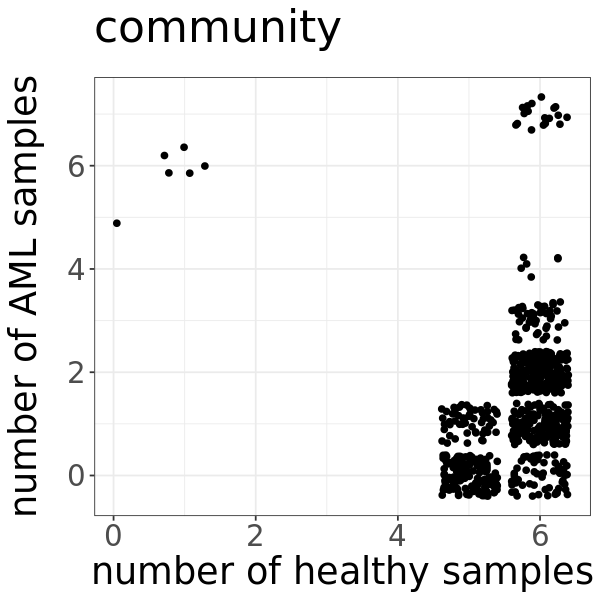

In [37]:
# sample coverage: community
idx_case <- community_interactions$anno_samples$case_or_control == "case"
non_zero_weights <- community_interactions$weights[idx_sign,] !=0
df <- data.frame(interaction_ID = community_interactions$anno_interactions$interaction_ID[idx_sign]
                ,number_healthy = rowSums(non_zero_weights[,!idx_case])
                ,number_aml = rowSums(non_zero_weights[,idx_case])
                )

plot_nr_samples(df,"community")

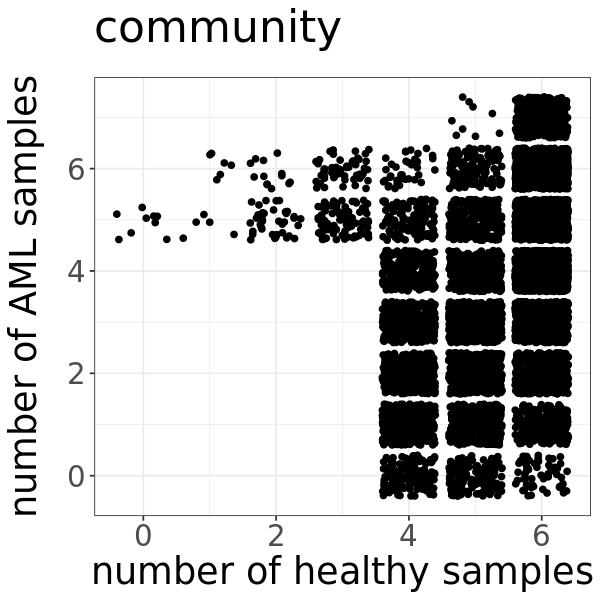

In [16]:
# sample coverage: community
idx_case <- community_interactions$anno_samples$case_or_control == "case"
non_zero_weights <- community_interactions$weights[idx_good,] !=0
df <- data.frame(interaction_ID = community_interactions$anno_interactions$interaction_ID[idx_good]
                ,number_healthy = rowSums(non_zero_weights[,!idx_case])
                ,number_aml = rowSums(non_zero_weights[,idx_case])
                )

plot_nr_samples(df,"community")

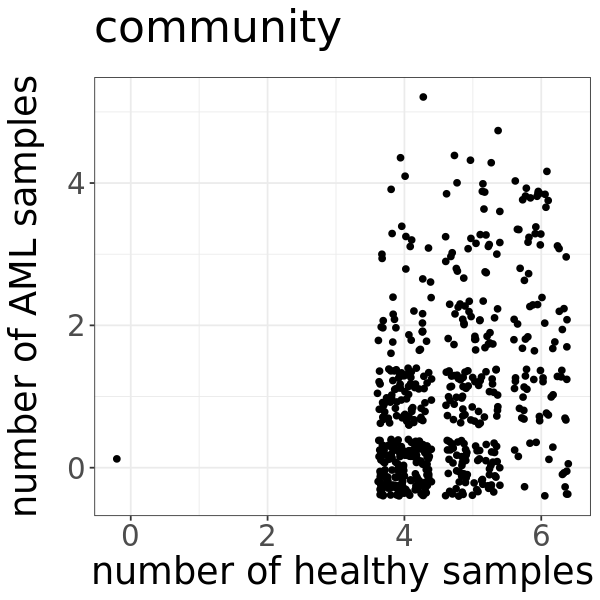

In [26]:
idx_bad <- (!community_interactions$anno_interactions$passed_QC_filter) & (community_interactions$anno_interactions$passed_frac_samples_filter)


# sample coverage: community
idx_case <- community_interactions$anno_samples$case_or_control == "case"
non_zero_weights <- community_interactions$weights[idx_bad,] !=0
df <- data.frame(interaction_ID = community_interactions$anno_interactions$interaction_ID[idx_bad]
                ,number_healthy = rowSums(non_zero_weights[,!idx_case])
                ,number_aml = rowSums(non_zero_weights[,idx_case])
                )


new_row <- data.frame(
  number_healthy = 0,
  number_aml = 0,
  interaction_ID = "pseudo_interaction"
)


df <- rbind(df, new_row)
plot_nr_samples(df,"community")

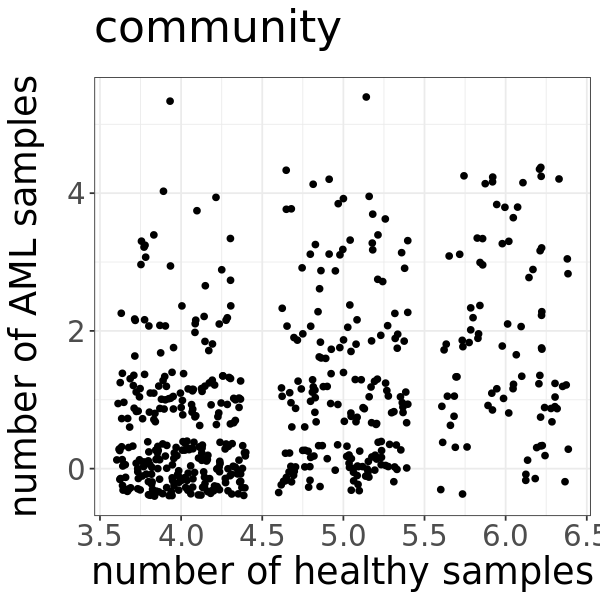

In [12]:
idx_bad <- (!community_interactions$anno_interactions$passed_QC_filter) & (community_interactions$anno_interactions$passed_frac_samples_filter)


# sample coverage: community
idx_case <- community_interactions$anno_samples$case_or_control == "case"
non_zero_weights <- community_interactions$weights[idx_bad,] !=0
df <- data.frame(interaction_ID = community_interactions$anno_interactions$interaction_ID[idx_bad]
                ,number_healthy = rowSums(non_zero_weights[,!idx_case])
                ,number_aml = rowSums(non_zero_weights[,idx_case])
                )

plot_nr_samples(df,"community")

In [68]:
idx_case <- grepl("AML",colnames(cpdb_interactions$weights))
non_zero_weights <- cpdb_interactions$weights !=0

In [69]:
sum(idx_case)

[1] 7

In [70]:
idx_control <- grepl("healthy",colnames(cpdb_interactions$weights))

In [71]:
sum(idx_control)

[1] 6

tibble [5,732 × 14] (S3: tbl_df/tbl/data.frame)
 $ interaction_ID: chr [1:5732] "B:ALCAM_NK:CD6" "DC:ALCAM_NK:CD6" "Gran:ALCAM_NK:CD6" "HSPC:ALCAM_NK:CD6" ...
 $ AML-0024      : int [1:5732] 0 1 1 0 1 0 1 1 0 1 ...
 $ AML-0160      : int [1:5732] 0 0 0 0 0 0 1 1 1 1 ...
 $ AML-0693      : int [1:5732] 0 0 0 0 0 1 1 1 1 1 ...
 $ AML-1371      : int [1:5732] 1 1 1 1 1 1 1 1 1 1 ...
 $ AML-2123      : int [1:5732] 0 0 1 1 1 0 0 1 1 1 ...
 $ AML-3133      : int [1:5732] 0 1 1 1 0 0 1 1 1 0 ...
 $ AML-4340      : int [1:5732] 0 1 1 1 1 0 1 1 1 1 ...
 $ healthy-1     : int [1:5732] 0 0 0 0 0 0 1 1 1 0 ...
 $ healthy-2     : int [1:5732] 0 0 0 0 0 0 1 1 1 0 ...
 $ healthy-3     : int [1:5732] 0 0 0 0 0 0 1 1 1 0 ...
 $ healthy-4     : int [1:5732] 0 0 0 0 0 0 1 1 1 0 ...
 $ healthy-4003  : int [1:5732] 0 0 0 0 0 0 1 1 1 0 ...
 $ healthy-5     : int [1:5732] 0 0 0 0 0 0 1 1 1 0 ...
 logi [1:5732, 1:14] TRUE TRUE TRUE TRUE TRUE TRUE ...
 - attr(*, "dimnames")=List of 2
  ..$ : chr [1:5732] "B:A

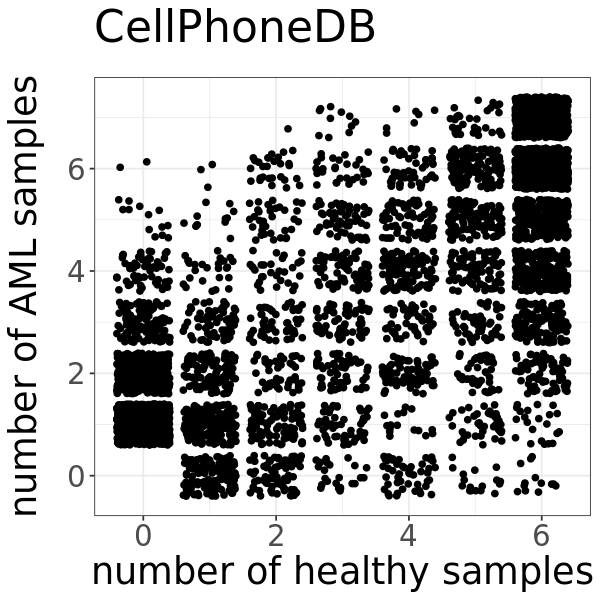

In [72]:
# sample coverage: CPDB
idx_case <- grepl("AML",colnames(cpdb_interactions$weights))
idx_control <- grepl("healthy",colnames(cpdb_interactions$weights))
non_zero_weights <- cpdb_interactions$weights !=0
str(cpdb_interactions$weights)
str(non_zero_weights)
df_cpdb <- data.frame(interaction_ID = rownames(cpdb_interactions$weights)
                ,number_healthy = rowSums(non_zero_weights[,idx_control])
                ,number_aml = rowSums(non_zero_weights[,idx_case])
                )


plot_nr_samples(df_cpdb, "CellPhoneDB")

In [73]:
df = nn_interactions$weights

In [74]:
# sign = nn_interactions$anno_interactions[nn_interactions$anno_interactions$sign == TRUE,]

In [75]:
# df = df[df$interaction_ID %in% sign$interaction_ID,]

In [76]:
rownames(df) = df$interaction_ID

Warning message:
“Setting row names on a tibble is deprecated.”


In [79]:
df_nn <- data.frame(interaction_ID = rownames(df)
                ,number_healthy = rowSums(df[,idx_control])
                ,number_aml = rowSums(df[,idx_case])
                )

In [447]:
min(df_nn$number_aml)

[1] 0

In [448]:
min(df_nn$number_healthy)

[1] 0

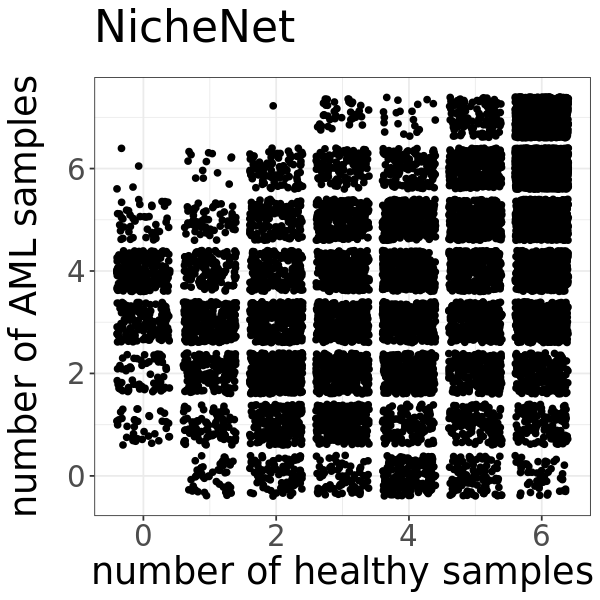

In [80]:
# sample coverage:NN
idx_case <- grepl("AML",colnames(nn_interactions$weights))
idx_control <- grepl("healthy",colnames(nn_interactions$weights))
# non_zero_weights <- !is.na(nn_interactions$weights)
# df_nn <- data.frame(interaction_ID = rownames(nn_interactions$weights)
#                 ,number_healthy = rowSums(non_zero_weights[,idx_control])
#                 ,number_aml = rowSums(non_zero_weights[,idx_case])
#                 )

# df_nn <- df_nn[c("number_healthy","number_aml")]


plot_nr_samples(df_nn, "NicheNet")

In [450]:
length(df_cpdb$interaction_ID)

[1] 5732

In [451]:
length(df_nn$interaction_ID)

[1] 14104

In [452]:
head(cellchat_interactions$weights)

,AML-0024,AML-0160,AML-0693,AML-1371,AML-2123,AML-3133,AML-4340,healthy-1,healthy-2,healthy-3,healthy-4,healthy-4003,healthy-5
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
NK:TGFB1_NK:TGFBR3,0.0069939380,NA,0.007884556,0.03626334,NA,0.018647469,NA,NA,NA,NA,NA,NA,NA
T:TGFB1_NK:TGFBR3,0.0059918655,NA,0.001992708,0.02866503,NA,0.011366258,NA,NA,NA,NA,NA,NA,NA
NK:TGFB1_T:TGFBR3,0.0009408477,NA,NA,0.01429447,NA,0.001715363,NA,NA,NA,NA,NA,NA,NA
T:TGFB1_T:TGFBR3,0.0008053422,NA,NA,0.01124562,NA,0.001038575,NA,NA,NA,NA,NA,NA,NA
Mono:ADM_DC:RAMP1,0.0100074770,5.467536e-05,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
Mono:ADM_NK:RAMP1,0.0055381506,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA


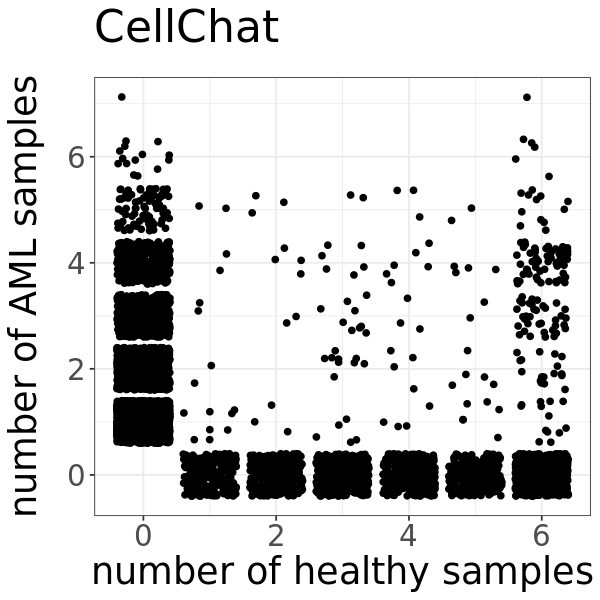

In [81]:
# sample coverage:CellCat
idx_case <- grepl("AML",colnames(cellchat_interactions$weights))
idx_control <- grepl("healthy",colnames(cellchat_interactions$weights))
non_zero_weights <- !is.na(cellchat_interactions$weights)
df_cc <- data.frame(interaction_ID = rownames(cellchat_interactions$weights)
                ,number_healthy = rowSums(non_zero_weights[,idx_control])
                ,number_aml = rowSums(non_zero_weights[,idx_case])
                )


plot_nr_samples(df_cc, "CellChat")

In [454]:
head(non_zero_weights[,idx_control])

,healthy-1,healthy-2,healthy-3,healthy-4,healthy-4003,healthy-5
NK:TGFB1_NK:TGFBR3,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE
T:TGFB1_NK:TGFBR3,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE
NK:TGFB1_T:TGFBR3,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE
T:TGFB1_T:TGFBR3,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE
Mono:ADM_DC:RAMP1,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE
Mono:ADM_NK:RAMP1,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE


In [455]:
head(scseqcom_interactions$weights)

,AML_1,AML_2,AML_3,AML_4,AML_5,AML_6,AML_7,healthy_1,healthy_2,healthy_3,healthy_4,healthy_5,healthy_6,interaction_ID
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
B:GAS6_B:MERTK,0.0000000,0.0000000,5.954193e-10,0.000000000,0.0000000,0.000000000,0.00000000,3.592641e-05,0.007875553,6.642645e-09,8.124245e-23,0.000000e+00,0.0005278951,B:GAS6_B:MERTK
B:LTA_B:TNFRSF14,0.3355021,0.2647137,7.549759e-09,0.002950618,0.1994098,0.001964705,0.02244861,4.351719e-04,0.000000000,7.580544e-04,2.151355e-17,2.844476e-04,0.0000000000,B:LTA_B:TNFRSF14
B:LTA_B:TNFRSF1B,0.3355021,0.2647137,7.549759e-09,0.002950618,0.1994098,0.001964705,0.02244861,4.351719e-04,0.000000000,7.580544e-04,2.151355e-17,2.844476e-04,0.0000000000,B:LTA_B:TNFRSF1B
B:GAS6_B:TYRO3,0.0000000,0.0000000,0.000000e+00,0.000000000,0.0000000,0.000000000,0.00000000,5.630645e-05,0.006292253,6.452323e-09,5.920724e-24,1.813069e-05,0.0007048456,B:GAS6_B:TYRO3
B:TNF_B:TNFRSF21,0.0000000,0.0000000,3.216296e-09,0.000000000,0.0000000,0.000000000,0.00000000,6.010160e-04,0.008860955,6.515376e-09,6.672071e-19,0.000000e+00,0.0006079496,B:TNF_B:TNFRSF21
B:ASIP_B:ATRN,0.0000000,0.0000000,0.000000e+00,0.000000000,0.0000000,0.000000000,0.00000000,0.000000e+00,0.000000000,1.774606e-08,1.714717e-23,2.229447e-05,0.0006030196,B:ASIP_B:ATRN


Warning message:
“Removed 6907 rows containing missing values or values outside the scale range (`geom_point()`).”
Warning message:
“Removed 6907 rows containing missing values or values outside the scale range (`geom_point()`).”


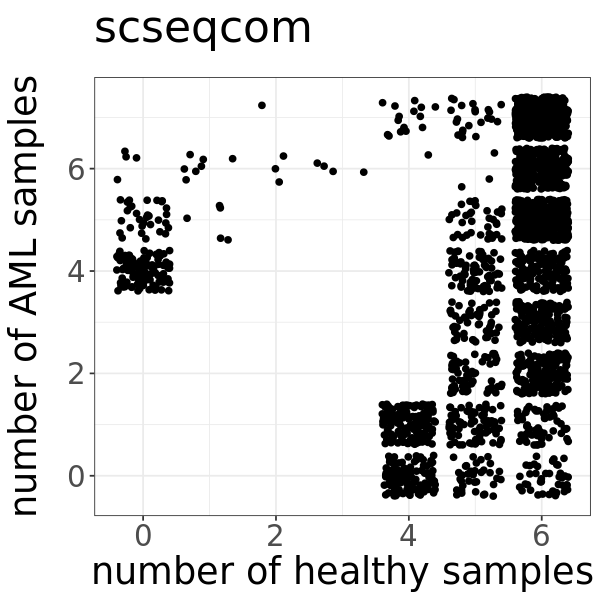

In [456]:
# sample coverage:scseqcom
idx_case <- grepl("AML",colnames(scseqcom_interactions$weights))
idx_control <- grepl("healthy",colnames(scseqcom_interactions$weights))
non_zero_weights <- scseqcom_interactions$weights !=0
df_scseq <- data.frame(interaction_ID = rownames(scseqcom_interactions$weights)
                ,number_healthy = rowSums(non_zero_weights[,idx_control])
                ,number_aml = rowSums(non_zero_weights[,idx_case])
                )


plot_nr_samples(df_scseq, "scseqcom")

In [82]:
idx_good_cpdb <- df_cpdb$number_healthy >= 5 | df_cpdb$number_aml >= 5
idx_good_nn <- df_nn$number_healthy >= 5 | df_nn$number_aml >= 5
idx_good_cc <- df_cc$number_healthy >= 5 | df_cc$number_aml >= 5
idx_good_scseq <- df_scseq$number_healthy >= 5 | df_scseq$number_aml >= 5

ERROR: Error in eval(expr, envir, enclos): object 'df_scseq' not found


In [83]:
sum(idx_good_cc)

[1] 1128

In [84]:
sum(idx_good_nn)

[1] 8954

In [478]:
# cellchat_interactions$weights

In [85]:
community_set1 <- community_interactions$anno_interactions$interaction_ID[idx_sign]
CellPhoneDB_set2 <- df_cpdb$interaction_ID[idx_good_cpdb]
NicheNet_set3 <- df_nn$interaction_ID[idx_good_nn]
CellChat_set4 <- df_cc$interaction_ID[idx_good_cc]
scSeqCom_set5 <- df_scseq$interaction_ID[idx_good_scseq]

ERROR: Error in eval(expr, envir, enclos): object 'df_scseq' not found


In [480]:
good_qc_interactions <- unique(c(community_set1, CellPhoneDB_set2, NicheNet_set3, CellChat_set4, scSeqCom_set5))

good_qc_interactions_df <- data.frame(
  interaction_ID = good_qc_interactions,
  community = good_qc_interactions %in% community_set1,
  CPDB = good_qc_interactions %in% CellPhoneDB_set2,
  NicheNet = good_qc_interactions %in% NicheNet_set3,
  CellChat = good_qc_interactions %in% CellChat_set4,
  scSeqCom = good_qc_interactions %in% scSeqCom_set5
)


In [481]:
write.csv(good_qc_interactions_df,"outs/good_qc_interactions_df.csv", row.names = FALSE)

In [363]:
length(CellPhoneDB_set2)

[1] 2851

In [202]:
venn_list <- list(
    Community = community_set1,
    CellPhoneDB = CellPhoneDB_set2,
    NicheNet = NicheNet_set3,
    CellChat = CellChat_set4
  )

In [203]:
set_sizes <- c(length(community_set1), length(CellPhoneDB_set2), length(NicheNet_set3), length(CellChat_set4))

category_names <- paste0(
    c("community", "CPDB", "NicheNet", "CellChat"), 
    "\n(", set_sizes, ")"
  )

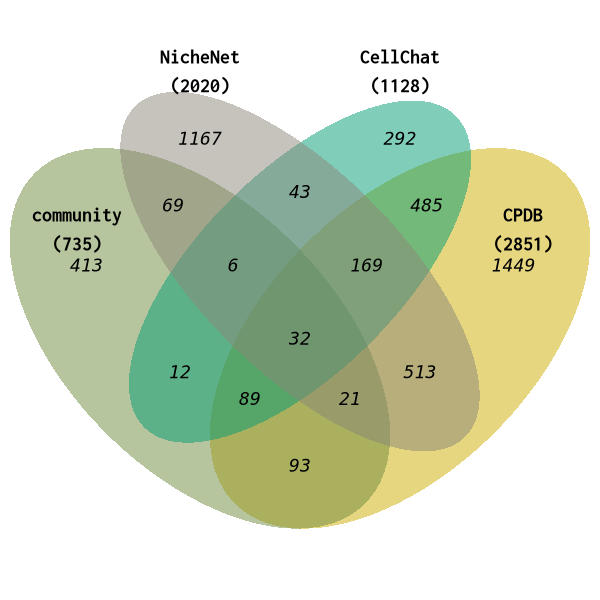

In [204]:
venn.plot <- venn.diagram(
    x = venn_list,
    category.names = category_names,  
    lwd = 2,
    lty = 'blank',
    fill = c("darkolivegreen4", "gold3", "cornsilk4", "#009E73"),
    cex = 0.9,
    fontface = "italic",
    cat.cex = 1,
    cat.fontface = "bold",
    cat.default.pos = "outer",
    cat.dist = c(0.055, 0.055, 0.1, 0.1),
    filename = NULL,  
    output = TRUE
  )
  
  ggsave(file="outs/good_QC_interactions.png", plot=venn.plot, width=10, height=8, dpi = 300)
  grid.draw(venn.plot)

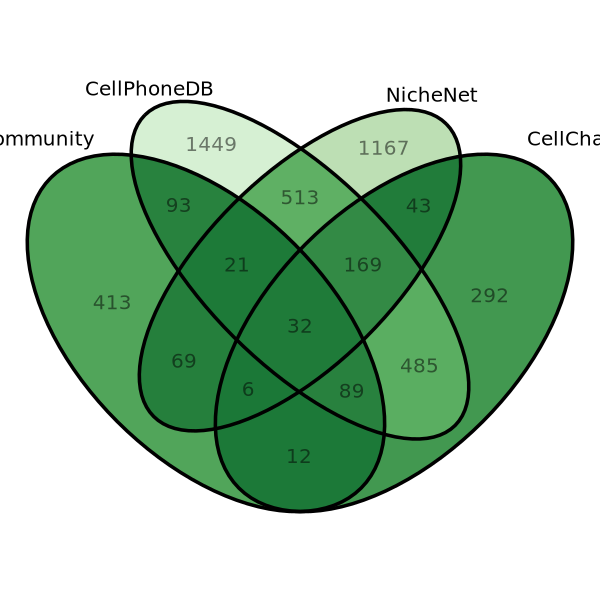

In [205]:
named_venn <- list(
"Community" = venn_list$Community,
"CellPhoneDB" = venn_list$CellPhoneDB,
"NicheNet" = venn_list$NicheNet,
"CellChat" = venn_list$CellChat
)

# Create the Venn diagram using ggVennDiagram
venn_plot <- ggVennDiagram(named_venn, label = "count", label_geom = "text") +
scale_fill_gradientn(colors = venn_colors) +  # Apply the gradient of colors
theme(legend.position = "none")  # Customize the theme

grid.draw(venn_plot)

In [463]:
idx_good_cpdb <- df_cpdb$number_healthy >= 5 | df_cpdb$number_aml >= 5
idx_good_nn <- df_nn$number_healthy >= 5 | df_nn$number_aml >= 5
idx_good_cc <- df_cc$number_healthy >= 5 | df_cc$number_aml >= 5


int_list <- list(community = community_interactions$anno_interactions$interaction_ID[idx_sign]
                ,NicheNet = df_nn$interaction_ID[idx_good_nn]
                ,CellPhoneDB = df_cpdb$interaction_ID[idx_good_cpdb]
                ,CellChat = df_cc$interaction_ID[idx_good_cc]
                )
print(str(int_list))

# add numbers to the names
numbers <- c(sum(idx_sign)
            ,sum(idx_good_nn)
            ,sum(idx_good_cpdb)
            ,sum(idx_good_cc)
            )
names(int_list) <- paste0(names(int_list)
                         ,"\n"
                         ,"("
                         ,numbers
                         ,")")

plot(euler(int_list
         # , shape = "ellipse"
          )
     ,fills = c(community = "darkolivegreen4"
                ,NicheNet = "gold3"
                ,CellPhoneDB = "cornsilk4"#"rosybrown"
               )
     ,alpha=c(1,0.5,0.5)
     ,quantities = list(fontsize = 12)
    )

List of 4
 $ community  : chr [1:735] "Mono:RETN_Mono:CAP1" "Mono:ANXA1_Gran:FPR1" "Mono:RETN_Gran:CAP1" "Mono:GNAI2_Gran:FPR1" ...
 $ NicheNet   : chr [1:8954] "Gran:RETN_Gran:CAP1" "Mono:ADAM17_DC:ITGA5" "B:LGALS1_B:CD69" "DC:HLA-DRB1_DC:CD4" ...
 $ CellPhoneDB: chr [1:2851] "Gran:ALCAM_NK:CD6" "DC:ALCAM_T:CD6" "Gran:ALCAM_T:CD6" "HSPC:ALCAM_T:CD6" ...
 $ CellChat   : chr [1:1128] "Mono:HLA-A_Mono:LILRB1" "NK:HLA-A_Mono:LILRB1" "T:HLA-A_Mono:LILRB1" "Mono:HLA-B_Mono:LILRB1" ...
NULL


ERROR: Error in euler(int_list): could not find function "euler"


## Alluvial plot of interactions

The direction of interaction chnges for CPDB and NN will be defined by using the log2FC of the ligand and the receptor. If one or both are upregulated, then the interaction is upregulated. If one or both are downregulated, the interaction is downregulated. If the ligand and the receptor is changed in the disconcordant direciton, then the interaction is ambigous.

In [86]:
head(cpdb_interactions$anno_interactions) 

,interaction_ID,sender_celltype,sender_gene,receiver_celltype,receiver_gene,ligand_log2FC,ligand_p_val_adj,receptor_log2FC,receptor_p_val_adj,direction,direction_lig,direction_rec,direction_lig_rec
,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>
1,B:ALCAM_NK:CD6,B,ALCAM,NK,CD6,NA,NA,0.2900217,5.625314e-50,up,NA,up,NA_up
2,DC:ALCAM_NK:CD6,DC,ALCAM,NK,CD6,NA,NA,0.2900217,5.625314e-50,up,NA,up,NA_up
3,Gran:ALCAM_NK:CD6,Gran,ALCAM,NK,CD6,NA,NA,0.2900217,5.625314e-50,up,NA,up,NA_up
4,HSPC:ALCAM_NK:CD6,HSPC,ALCAM,NK,CD6,NA,NA,0.2900217,5.625314e-50,up,NA,up,NA_up
5,Mono:ALCAM_NK:CD6,Mono,ALCAM,NK,CD6,NA,NA,0.2900217,5.625314e-50,up,NA,up,NA_up
6,B:ALCAM_T:CD6,B,ALCAM,T,CD6,NA,NA,0.2785492,7.678829e-119,up,NA,up,NA_up


In [87]:
head(nn_interactions$anno_interactions) 

,group,sender,receiver,ligand,receptor,id,prioritization_score,prioritization_rank,ligand_p_val,ligand_logFC,receptor_p_val,receptor_logFC,interaction_ID,direction_lig,direction_rec,direction_lig_rec,direction,community_QC
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>
1,healthy,Gran,Gran,RETN,CAP1,RETN_CAP1_Gran_Gran,0.9483442,1,0.00422,-1.700,0.20400,-0.272,Gran:RETN_Gran:CAP1,down,down,down_down,down,TRUE
2,AML,Mono,DC,ADAM17,ITGA5,ADAM17_ITGA5_Mono_DC,0.9242482,2,0.00202,0.870,0.00807,1.370,Mono:ADAM17_DC:ITGA5,up,up,up_up,up,FALSE
3,AML,B,B,LGALS1,CD69,LGALS1_CD69_B_B,0.9238217,3,0.00159,1.170,0.14800,0.646,B:LGALS1_B:CD69,up,up,up_up,up,TRUE
4,healthy,DC,DC,HLA.DRB1,CD4,HLA.DRB1_CD4_DC_DC,0.9200506,4,0.01570,-0.380,0.11400,-0.624,DC:HLA-DRB1_DC:CD4,down,down,down_down,down,TRUE
5,healthy,Mono,DC,HLA.DRB1,CD4,HLA.DRB1_CD4_Mono_DC,0.9187556,5,0.00481,-0.824,0.11400,-0.624,Mono:HLA-DRB1_DC:CD4,down,down,down_down,down,TRUE
6,healthy,Ery,Ery,TRIP6,ENG,TRIP6_ENG_Ery_Ery,0.9178610,6,0.00108,-1.200,0.02720,-0.703,Ery:TRIP6_Ery:ENG,down,down,down_down,down,FALSE


In [484]:
#Assigned CPDB directions

In [88]:
# assign direction to the intersctions in community
idx_down <- community_interactions$anno_interactions$log2FC_weights < 0
idx_up <- community_interactions$anno_interactions$log2FC_weights > 0

community_interactions$anno_interactions$direction <- NA
community_interactions$anno_interactions$direction[idx_down] <- "down"
community_interactions$anno_interactions$direction[idx_up] <- "up"
community_interactions$anno_interactions$direction[!idx_sign] <- "not significant"

In [89]:
table(community_interactions$anno_interactions$direction)


           down not significant              up 
            726          151009               9 

In [90]:
table(cpdb_interactions$anno_interactions$direction)


ambigous     down       up 
     164     2289     3279 

In [91]:
table(nn_interactions$anno_interactions$direction)


ambigous     down       up 
    4293     9292      519 

In [92]:
table(cellchat_interactions$anno_interactions$direction)


ambigous     down       up 
    1637     1413     3372 

In [490]:
table(scseqcom_interactions$anno_interactions$direction)


down   up 
7207 2174 

In [93]:
sum(idx_good_nn)

[1] 8954

In [94]:
int_alluvial <- unique(c(community_interactions$anno_interactions$interaction_ID[idx_sign]
                         ,df_cpdb$interaction_ID[idx_good_cpdb]
                         ,df_nn$interaction_ID[idx_good_nn]
                         ,df_cc$df_cc$interaction_ID[idx_good_cc]
                         # ,df_scseq$interaction_ID[idx_good_scseq]
                            )
                )
print(str(int_alluvial))

 chr [1:9094] "Mono:RETN_Mono:CAP1" "Mono:ANXA1_Gran:FPR1" ...
NULL


In [254]:
# # prepare the df for plotting
# # all three algorithms
# rownames(community_interactions$anno_interactions) <- community_interactions$anno_interactions$interaction_ID
# rownames(cpdb_interactions$anno_interactions) <- cpdb_interactions$anno_interactions$interaction_ID
# rownames(nn_interactions$anno_interactions) <- nn_interactions$anno_interactions$interaction_ID
# rownames(cellchat_interactions$anno_interactions) <- cellchat_interactions$anno_interactions$interaction_ID
# rownames(scseqcom_interactions$anno_interactions) <- scseqcom_interactions$anno_interactions$interaction_ID

# df_facets <- data.frame(interaction_ID = int_alluvial
#                        ,community_sign = community_interactions$anno_interactions[int_alluvial,"sign"]
#                        ,community_log2FC_weights = community_interactions$anno_interactions[int_alluvial,"log2FC_weights"]
#                         ,community = rep(NA,length(int_alluvial))
#                        ,CellPhoneDB = cpdb_interactions$anno_interactions[int_alluvial,"direction"]
#                        ,NicheNet = nn_interactions$anno_interactions[int_alluvial,"direction"]
#                        ,CellChat = cellchat_interactions$anno_interactions[int_alluvial,"direction"]
#                         ,scSeqCom = scseqcom_interactions$anno_interactions[int_alluvial,"direction"]
#                        )


# # simplify the categories for community
# df_facets$community_sign[is.na(df_facets$community_sign)] <- FALSE

# df_facets$community[(df_facets$community_sign) & (df_facets$community_log2FC_weights > 1)] <- "up"
# df_facets$community[(df_facets$community_sign) & (df_facets$community_log2FC_weights < -1)] <- "down"
# df_facets$community[!df_facets$community_sign] <- "not\nsignificant"

# # present in community but not in CPDB
# df_facets$CellPhoneDB[is.na(df_facets$CellPhoneDB)] <- "not\nsignificant"

# # present in community but not in NN
# df_facets$NicheNet[is.na(df_facets$NicheNet)] <- "not\nsignificant"

# # present in community but not in CellChat
# df_facets$CellChat[is.na(df_facets$CellChat)] <- "not\nsignificant"


# # present in community but not in scSeqCom
# df_facets$scSeqCom[is.na(df_facets$scSeqCom)] <- "not\nsignificant"

In [170]:
# df_com_scseq = df_facets[df_facets$community == df_facets$scSeqCom,]

In [92]:
# dim(df_com_scseq)

[1] 3632    8

In [94]:
# df_facets[!df_facets$community == df_facets$scSeqCom,]

In [95]:
# df_com_scseq[df_com_scseq$scSeqCom == "not\nsignificant",]

In [120]:
# df_facets$comparison <- sapply(1:nrow(df_facets)
#                                ,function(i) {
#                                    paste(df_facets[i,c("community","CellPhoneDB","NicheNet","CellChat", "scSeqCom")]
#                                         ,collapse = " ")
#                                })

In [122]:
# df_facets$freq <- table(df_facets$comparison)[df_facets$comparison]


In [129]:
# df_facets[!duplicated(df_facets$comparison),]

In [95]:
table(nn_interactions$anno_interactions$direction)


ambigous     down       up 
    4293     9292      519 

In [97]:
# prepare the df for plotting
# all three algorithms
rownames(community_interactions$anno_interactions) <- community_interactions$anno_interactions$interaction_ID
rownames(cpdb_interactions$anno_interactions) <- cpdb_interactions$anno_interactions$interaction_ID
rownames(nn_interactions$anno_interactions) <- nn_interactions$anno_interactions$interaction_ID
rownames(cellchat_interactions$anno_interactions) <- cellchat_interactions$anno_interactions$interaction_ID

df_facets <- data.frame(interaction_ID = int_alluvial
                       ,community_sign = community_interactions$anno_interactions[int_alluvial,"sign"]
                       ,community_log2FC_weights = community_interactions$anno_interactions[int_alluvial,"log2FC_weights"]
                        ,community = rep(NA,length(int_alluvial))
                       ,CellPhoneDB = cpdb_interactions$anno_interactions[int_alluvial,"direction"]
                       ,NicheNet = nn_interactions$anno_interactions[int_alluvial,"direction"]
                       ,CellChat = cellchat_interactions$anno_interactions[int_alluvial,"direction"] 
                       )

# simplify the categories for community
df_facets$community_sign[is.na(df_facets$community_sign)] <- FALSE

df_facets$community[(df_facets$community_sign) & (df_facets$community_log2FC_weights > 1)] <- "up"
df_facets$community[(df_facets$community_sign) & (df_facets$community_log2FC_weights < -1)] <- "down"
df_facets$community[!df_facets$community_sign] <- "not\nsignificant"

# present in community but not in CPDB
df_facets$CellPhoneDB[is.na(df_facets$CellPhoneDB)] <- "not\nsignificant"

# present in community but not in NN
df_facets$NicheNet[is.na(df_facets$NicheNet)] <- "not\nsignificant"

# present in community but not in CellChat
df_facets$CellChat[is.na(df_facets$CellChat)] <- "not\nsignificant"

df_facets$comparison <- sapply(1:nrow(df_facets)
                               ,function(i) {
                                   paste(df_facets[i,c("community","CellPhoneDB","NicheNet","CellChat")]
                                        ,collapse = " ")
                               })

df_facets$freq <- table(df_facets$comparison)[df_facets$comparison]
df_facets <- df_facets[!duplicated(df_facets$comparison),]


df_facets$community <- factor(df_facets$community
                                  ,levels = c("up"
                                              ,"down"
                                              ,"not\nsignificant"
                                             )
                                  ,ordered = TRUE)

df_facets$CellPhoneDB <- factor(df_facets$CellPhoneDB
                                  ,levels = c("up"
                                              ,"down"
                                              ,"ambigous"
                                              ,"not\nsignificant"
                                             )
                                  ,ordered = TRUE)

df_facets$NicheNet <- factor(df_facets$NicheNet
                                  ,levels = c("up"
                                              ,"down"
                                              ,"ambigous"
                                              ,"not\nsignificant"
                                             )
                                  ,ordered = TRUE)

df_facets$CellChat <- factor(df_facets$CellChat
                                  ,levels = c("up"
                                              ,"down"
                                              ,"ambigous"
                                              ,"not\nsignificant"
                                             )
                                  ,ordered = TRUE)

print((df_facets))

               interaction_ID community_sign community_log2FC_weights
1         Mono:RETN_Mono:CAP1           TRUE             -1.166357016
2        Mono:ANXA1_Gran:FPR1           TRUE            -14.978926220
4        Mono:GNAI2_Gran:FPR1           TRUE            -14.896663635
12          Mono:RETN_NK:CAP1           TRUE            -13.359876038
16        Mono:AGTRAP_B:RACK1           TRUE             -2.748816847
29        Mono:ARF6_HSPC:PLD1           TRUE              6.491996642
31     Mono:S100A12_HSPC:CD36           TRUE            -13.145730880
33      Mono:S100A9_HSPC:CD68           TRUE              6.545726007
39        Mono:APP_HSPC:LRP10           TRUE            -12.098411908
55       Mono:ADAM17_Ery:MUC1           TRUE             -1.977234358
66      Mono:LRPAP1_Ery:CD320           TRUE             -5.003770907
81        Mono:BST2_DC:LILRA4           TRUE             -7.767006809
84         Mono:THBS1_DC:CD36           TRUE             -7.606394638
86       Mono:HLA-C_

In [96]:
# # prepare the df for plotting
# # all three algorithms
# rownames(community_interactions$anno_interactions) <- community_interactions$anno_interactions$interaction_ID
# rownames(cpdb_interactions$anno_interactions) <- cpdb_interactions$anno_interactions$interaction_ID
# rownames(nn_interactions$anno_interactions) <- nn_interactions$anno_interactions$interaction_ID
# rownames(cellchat_interactions$anno_interactions) <- cellchat_interactions$anno_interactions$interaction_ID
# rownames(scseqcom_interactions$anno_interactions) <- scseqcom_interactions$anno_interactions$interaction_ID

# df_facets <- data.frame(interaction_ID = int_alluvial
#                        ,community_sign = community_interactions$anno_interactions[int_alluvial,"sign"]
#                        ,community_log2FC_weights = community_interactions$anno_interactions[int_alluvial,"log2FC_weights"]
#                         ,community = rep(NA,length(int_alluvial))
#                        ,CellPhoneDB = cpdb_interactions$anno_interactions[int_alluvial,"direction"]
#                        ,NicheNet = nn_interactions$anno_interactions[int_alluvial,"direction"]
#                        ,CellChat = cellchat_interactions$anno_interactions[int_alluvial,"direction"]
#                         ,scSeqCom = scseqcom_interactions$anno_interactions[int_alluvial,"direction"]
#                        )

# # simplify the categories for community
# df_facets$community_sign[is.na(df_facets$community_sign)] <- FALSE

# df_facets$community[(df_facets$community_sign) & (df_facets$community_log2FC_weights > 1)] <- "up"
# df_facets$community[(df_facets$community_sign) & (df_facets$community_log2FC_weights < -1)] <- "down"
# df_facets$community[!df_facets$community_sign] <- "not\nsignificant"

# # present in community but not in CPDB
# df_facets$CellPhoneDB[is.na(df_facets$CellPhoneDB)] <- "not\nsignificant"

# # present in community but not in NN
# df_facets$NicheNet[is.na(df_facets$NicheNet)] <- "not\nsignificant"

# # present in community but not in CellChat
# df_facets$CellChat[is.na(df_facets$CellChat)] <- "not\nsignificant"


# # # present in community but not in scSeqCom
# df_facets$scSeqCom[is.na(df_facets$scSeqCom)] <- "not\nsignificant"

# df_facets$comparison <- sapply(1:nrow(df_facets)
#                                ,function(i) {
#                                    paste(df_facets[i,c("community","CellPhoneDB","NicheNet","CellChat", "scSeqCom")]
#                                         ,collapse = " ")
#                                })

# df_facets$freq <- table(df_facets$comparison)[df_facets$comparison]
# df_facets <- df_facets[!duplicated(df_facets$comparison),]


# df_facets$community <- factor(df_facets$community
#                                   ,levels = c("up"
#                                               ,"down"
#                                               ,"not\nsignificant"
#                                              )
#                                   ,ordered = TRUE)

# df_facets$CellPhoneDB <- factor(df_facets$CellPhoneDB
#                                   ,levels = c("up"
#                                               ,"down"
#                                               ,"ambigous"
#                                               ,"not\nsignificant"
#                                              )
#                                   ,ordered = TRUE)

# df_facets$NicheNet <- factor(df_facets$NicheNet
#                                   ,levels = c("up"
#                                               ,"down"
#                                               ,"ambigous"
#                                               ,"not\nsignificant"
#                                              )
#                                   ,ordered = TRUE)

# df_facets$CellChat <- factor(df_facets$CellChat
#                                   ,levels = c("up"
#                                               ,"down"
#                                               ,"ambigous"
#                                               ,"not\nsignificant"
#                                              )
#                                   ,ordered = TRUE)



# df_facets$scSeqCom <- factor(df_facets$scSeqCom
#                             ,levels = c("up"
#                                               ,"down"
#                                               ,"ambigous"
#                                               ,"not\nsignificant"
#                                              )
#                                   ,ordered = TRUE)


# str((df_facets))

In [354]:
# df_facets_pre = df_facets

In [98]:
# prepare colors for plotting
category_colors <- c("not\nsignificant" = "gray90"
                     ,"down" = "lightslateblue"
                     ,"up" = "red3"
                     ,"ambigous" = "darkorchid1"
                    )

In [99]:
levels(df_facets$community)

[1] "up"               "down"             "not\nsignificant"

In [100]:
levels(df_facets$CellPhoneDB)

[1] "up"               "down"             "ambigous"         "not\nsignificant"

In [101]:
levels(df_facets$NicheNet)

[1] "up"               "down"             "ambigous"         "not\nsignificant"

In [102]:
levels(df_facets$CellChat)

[1] "up"               "down"             "ambigous"         "not\nsignificant"

In [502]:
levels(df_facets$scSeqCom)

[1] "up"               "down"             "ambigous"         "not\nsignificant"

In [503]:
# options(repr.plot.width = 8
#        ,repr.plot.height = 8
#        )
# alluvial_plot <- ggplot(df_facets,
#        aes(y = freq,
#            axis1 = community 
#            ,axis2 = CellPhoneDB
#            ,axis3 = NicheNet
#            ,axis4 = CellChat
#            ,axis5 = scSeqCom
#           )
#       ) +
# geom_alluvium(aes(fill = community))+
# scale_fill_manual(values = category_colors)+
# geom_stratum(fill = "white"
#             ,linewidth = 0
#             #,width = 0.55
#             )+
# geom_stratum(alpha = 0.5
#              ,fill = category_colors[c("not\nsignificant"
#                                        ,"down"
#                                        ,"up"
                                       
#                                       ,"ambigous"
#                                        ,"not\nsignificant"
#                                        ,"down"
#                                        ,"up"
                                      
#                                       ,"ambigous"
#                                        ,"not\nsignificant"
#                                        ,"down"
#                                        ,"up"

#                                        ,"ambigous"
#                                        ,"not\nsignificant"
#                                        ,"down"
#                                        ,"up"


#                                        ,"not\nsignificant"
#                                        ,"down"
#                                        ,"up"
#                                       )
#                                     ]
#             ,linewidth = 0.1
#             )

Don't know how to automatically pick scale for object of type <table>. Defaulting to continuous.
Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
“Some strata appear at multiple axes.”
Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
“Some strata appear at multiple axes.”
Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
“Some strata appear at multiple axes.”


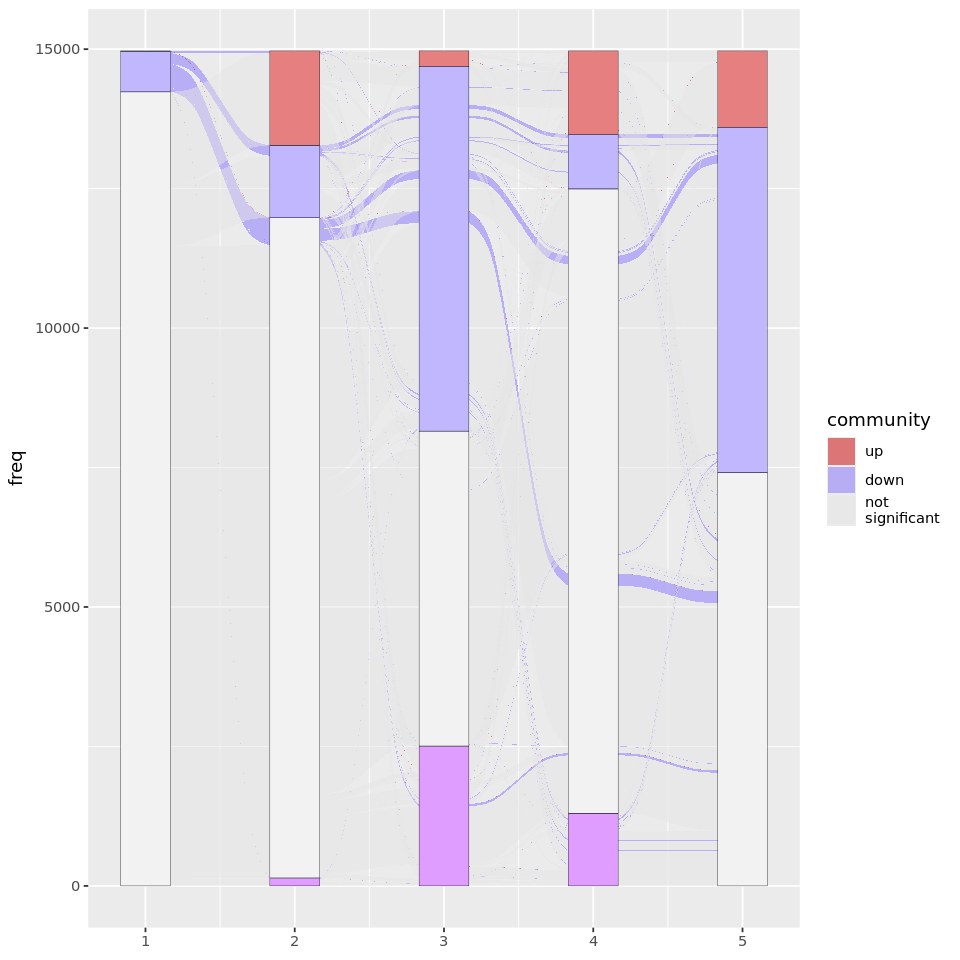

In [504]:
# alluvial_plot

Don't know how to automatically pick scale for object of type <table>. Defaulting to continuous.
Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
“Some strata appear at multiple axes.”
Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
“Some strata appear at multiple axes.”
Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
“Some strata appear at multiple axes.”
Don't know how to automatically pick scale for object of type <table>. Defaulting to continuous.
Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
“Some strata appear at multiple axes.”
Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
“Some strata appear at multiple axes.”
Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
“Some strata appear at multiple axes.”


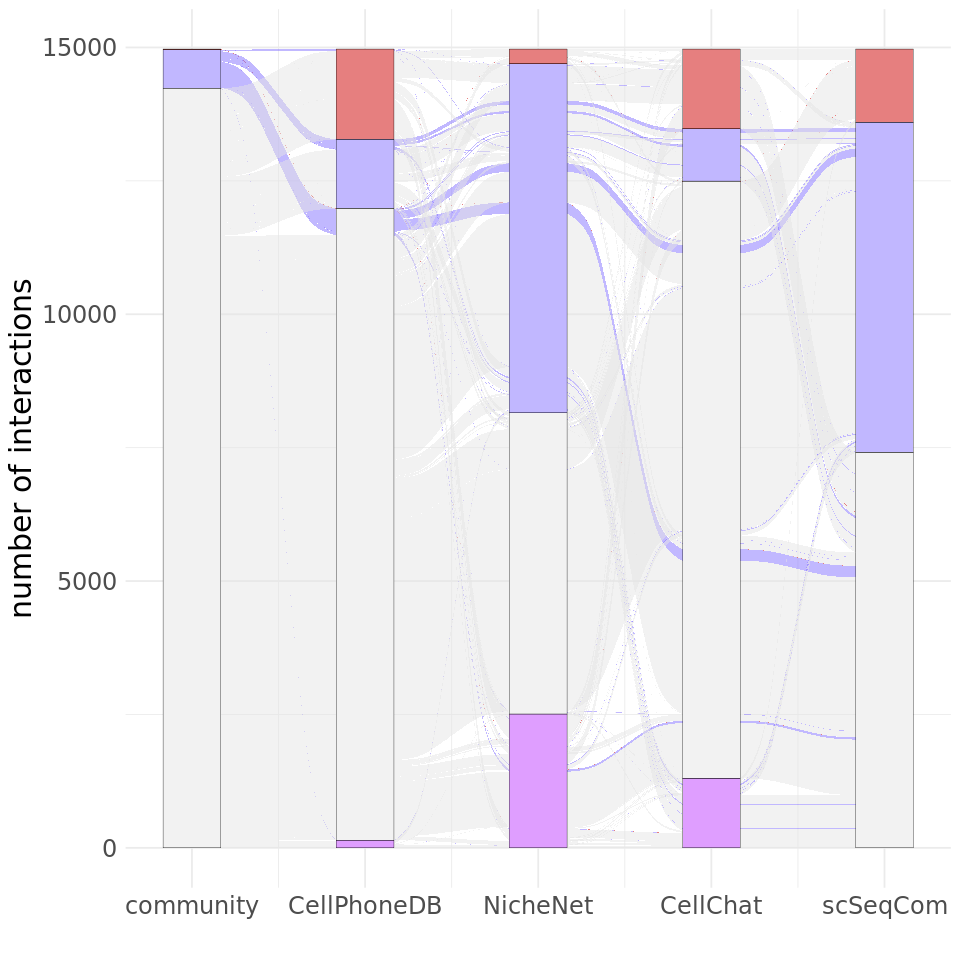

In [505]:
# # plot alluvial

# options(repr.plot.width = 8
#        ,repr.plot.height = 8
#        )
# alluvial_plot <- ggplot(df_facets,
#        aes(y = freq,
#            axis1 = community 
#            ,axis2 = CellPhoneDB
#            ,axis3 = NicheNet
#            ,axis4 = CellChat
#            ,axis5 = scSeqCom
#           )
#       ) +
# geom_alluvium(aes(fill = community)
#             #,width = 1/4
#              )+
# scale_fill_manual(values = category_colors)+
# geom_stratum(fill = "white"
#             ,linewidth = 0
#             #,width = 0.55
#             )+
# geom_stratum(alpha = 0.5
#              ,fill = category_colors[c("not\nsignificant"
#                                        ,"down"
#                                        ,"up"
                                       
#                                       ,"ambigous"
#                                        ,"not\nsignificant"
#                                        ,"down"
#                                        ,"up"
                                      
#                                       ,"ambigous"
#                                        ,"not\nsignificant"
#                                        ,"down"
#                                        ,"up"

#                                        ,"ambigous"
#                                        ,"not\nsignificant"
#                                        ,"down"
#                                        ,"up"

#                                        ,"not\nsignificant"
#                                        ,"down"
#                                        ,"up"
#                                       )
#                                     ]
#             ,linewidth = 0.1
#             )+
# # geom_text(stat = "stratum"
# #           ,aes(label = after_stat(stratum))
# #          ) +
# ylab("number of interactions")+
# xlab("")+
# scale_x_continuous(breaks = 1:5
#                    ,labels = c("community", "CellPhoneDB", "NicheNet","CellChat","scSeqCom")
                   
#                   ) +
# theme_minimal()+
# theme(legend.position="none"
#      ,text = element_text(size = 18)
#      )

# ggsave(file="outs/aluvial.png", plot=alluvial_plot, width=10, height=8, dpi = 300)

# alluvial_plot

Don't know how to automatically pick scale for object of type <table>. Defaulting to continuous.
Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
“Some strata appear at multiple axes.”
Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
“Some strata appear at multiple axes.”
Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
“Some strata appear at multiple axes.”
Don't know how to automatically pick scale for object of type <table>. Defaulting to continuous.
Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
“Some strata appear at multiple axes.”
Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
“Some strata appear at multiple axes.”
Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
“Some strata appear at multiple axes.”


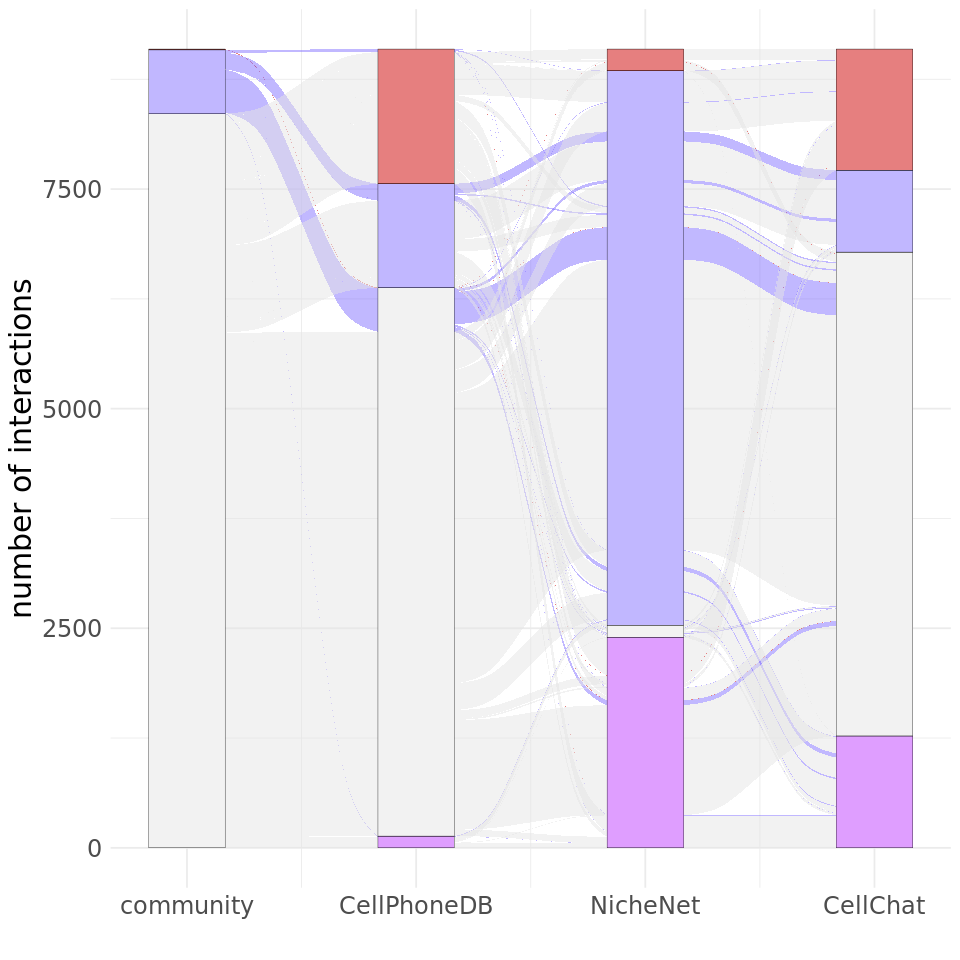

In [103]:
# plot alluvial

options(repr.plot.width = 8
       ,repr.plot.height = 8
       )
alluvial_plot <- ggplot(df_facets,
       aes(y = freq,
           axis1 = community 
           ,axis2 = CellPhoneDB
           ,axis3 = NicheNet
           ,axis4 = CellChat
          )
      ) +
geom_alluvium(aes(fill = community)
            #,width = 1/4
             )+
scale_fill_manual(values = category_colors)+
geom_stratum(fill = "white"
            ,linewidth = 0
            #,width = 0.55
            )+
geom_stratum(alpha = 0.5
             ,fill = category_colors[c("not\nsignificant"
                                       ,"down"
                                       ,"up"
                                       
                                      ,"ambigous"
                                       ,"not\nsignificant"
                                       ,"down"
                                       ,"up"
                                      
                                      ,"ambigous"
                                       ,"not\nsignificant"
                                       ,"down"
                                       ,"up"

                                       ,"ambigous"
                                       ,"not\nsignificant"
                                       ,"down"
                                       ,"up"
                                      )
                                    ]
            ,linewidth = 0.1
            )+
# geom_text(stat = "stratum"
#           ,aes(label = after_stat(stratum))
#          ) +
ylab("number of interactions")+
xlab("")+
scale_x_continuous(breaks = 1:4
                   ,labels = c("community", "CellPhoneDB", "NicheNet","CellChat")
                   
                  ) +
theme_minimal()+
theme(legend.position="none"
     ,text = element_text(size = 18)
     )

ggsave(file="outs/aluvial.png", plot=alluvial_plot, width=10, height=8, dpi = 300)

alluvial_plot

## Mono:HMGB1_T:CXCR4 interaction

In [223]:
plot_fractions <- function(interaction_ID
                           ,send_or_rec
                           ,health_status
                           ,colors
                          ,my_interactions
                           ,filename
                          ,plot.width=3.5){
    idx_my_interaction <- community_interactions$anno_interactions$interaction_ID == interaction_ID

    ifelse(send_or_rec == "sender"
          ,which_fraction  <-  "f_s"
          ,which_fraction  <- "f_r")
    df <- data.frame(fraction = unlist(my_interactions[[which_fraction]][idx_my_interaction,])
                    ,health_status = my_interactions$anno_samples$health_status
                     ,sample_ID = my_interactions$anno_samples$sample_ID
                    )
    
    # check if we need to re-assign health_status
    if("monocytic\nAML" %in% health_status){
        idx_AML_mono <- df$sample_ID %in% c("AML-0024","AML-0160")
        idx_AML <- grepl("AML",df$sample_ID)
        df$health_status[idx_AML_mono] <- "monocytic\nAML"
        df$health_status[idx_AML & !idx_AML_mono] <- "other\nAML"
    }
    
    df$health_status <- factor(df$health_status
                              ,levels = health_status
                              ,ordered = TRUE)
    
    ifelse(send_or_rec == "sender"
          ,cell_type <- "monocytes"
          ,cell_type <- "T cells"
          )
    
    
    options(repr.plot.height = 3
        ,repr.plot.width = plot.width)
    
    plot <- ggplot(data = df
          ,aes(x = health_status
              ,y = fraction
              ,fill = health_status)
          )+
    geom_boxplot(show.legend = FALSE
                ,alpha = 0.75)+
    geom_point(show.legend = FALSE)+
    scale_fill_manual(values = colors)+
    xlab("")+
    ylab("cell type abundance")+
    ggtitle(paste0(send_or_rec, ": ",cell_type))+
    theme_bw()+
    theme(text = element_text(size=18)
          ,axis.title.y = element_text(margin = margin(t = 0, r = 10, b = 0, l = 0))
          ,axis.ticks.x = element_blank()
          ,axis.text.x=element_text(size=18)
         )

    ggsave(file=filename, plot=plot, width=10, height=8, dpi = 300)

    plot
}

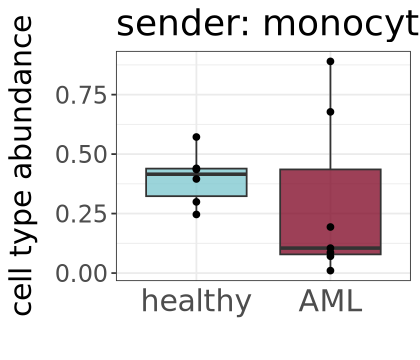

In [224]:
plot_fractions("Mono:HMGB1_T:CXCR4"
              ,"sender"
               ,c("healthy", "AML")
               ,c("#7ac5cd" # CadetBlue3 for healthy
                 ,"#7C001F") # bordeau for AML
              ,community_interactions, "outs/mono_sender.png")

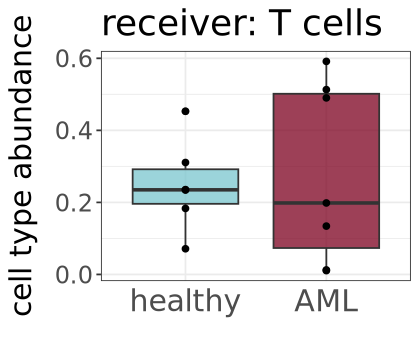

In [225]:
plot_fractions("Mono:HMGB1_T:CXCR4"
              ,"receiver"
               ,c("healthy", "AML")
               ,c("#7ac5cd" # CadetBlue3 for healthy
                 ,"#7C001F") # bordeau for AML
              ,community_interactions, "outs/t_receiver.png")

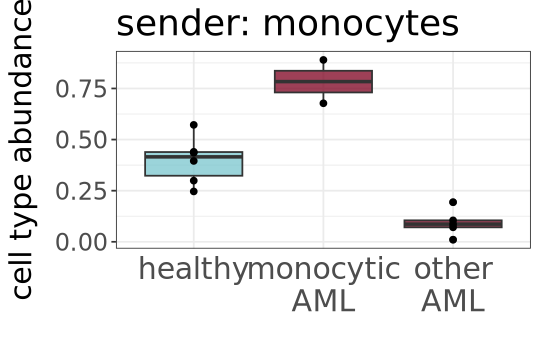

In [226]:
plot_fractions("Mono:HMGB1_T:CXCR4"
              ,"sender"
               ,c("healthy", "monocytic\nAML", "other\nAML")
               ,c("#7ac5cd" # CadetBlue3 for healthy
                 ,"#7C001F" # bordeau for AML
                 ,"#7C001F") # bordeau for AML_mono
              ,community_interactions
               ,"outs/monocytic_sender.png"
              ,plot.width = 4.5)

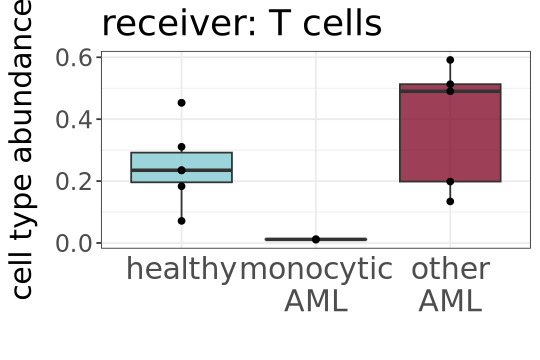

In [227]:
plot_fractions("Mono:HMGB1_T:CXCR4"
              ,"receiver"
               ,c("healthy", "monocytic\nAML", "other\nAML")
               ,c("#7ac5cd" # CadetBlue3 for healthy
                 ,"#7C001F" # bordeau for AML
                 ,"#7C001F") # bordeau for AML_mono
              ,community_interactions
              ,"outs/monocytic_sender.png"
              ,plot.width = 4.5)

In [394]:
sessionInfo()

R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: CentOS Linux 7 (Core)

Matrix products: default
BLAS/LAPACK: /work/project/ladcol_011/conda_path/miniconda3/envs/single_cell_env/lib/libopenblasp-r0.3.27.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=de_DE.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=de_DE.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=de_DE.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=de_DE.UTF-8 LC_IDENTIFICATION=C       

time zone: Europe/Berlin
tzcode source: system (glibc)

attached base packages:
[1] grid      stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
[1] ggalluvial_0.12.5   eulerr_7.0.2        svglite_2.1.3      
[4] VennDiagram_1.7.3   futile.logger_1.4.3 ggplot2_3.5.1      

loaded via a namespace (and not attached):
 [1